In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import fligner
from statannotations.Annotator import Annotator # Per le parentesi statistiche nei plot

# 1.2 Importazione e pulizia
file_path = "D:/Serena_project_deepethogram/sum_frames_xRstudio.csv"
df = pd.read_csv(file_path)

exclude_list = ["background", "Background", "inattentive", "Inattentive", "pecking", "Pecking"]

# Filtraggio e calcolo percentuali
df = df[~df['Behavior'].isin(exclude_list)].copy()
df['Percentage'] = (df['Frames'] / 5934) * 100

# Definizione ordini fattori (Categorical)
df['Behavior'] = pd.Categorical(df['Behavior'], categories=["headshaking", "beakwiping", "preening", "scratching"], ordered=True)
df['Condition'] = pd.Categorical(df['Condition'], categories=["A", "O", "C"], ordered=True)
print(df)

    Subject Condition     Behavior  Frames  Percentage
1     A10.1         A  headshaking      69    1.162791
2     A10.1         A   beakwiping      10    0.168520
3     A10.1         A   scratching       0    0.000000
4     A10.1         A     preening       0    0.000000
8     A11.1         A  headshaking     221    3.724301
..      ...       ...          ...     ...         ...
557    O8.3         O     preening      63    1.061678
561    O9.1         O  headshaking      61    1.027974
562    O9.1         O   beakwiping      62    1.044826
563    O9.1         O   scratching      80    1.348163
564    O9.1         O     preening     162    2.730030

[324 rows x 5 columns]


In [2]:
# 2.1 Tabella descrittiva master
descriptive_table = df.groupby(['Behavior', 'Condition'], observed=True)['Percentage'].agg(
    n='count',
    mean='mean',
    sd='std',
    median='median'
).reset_index()

descriptive_table['sem'] = descriptive_table['sd'] / np.sqrt(descriptive_table['n'])
descriptive_table = descriptive_table.round(4)

print("--- FINAL DESCRIPTIVE TABLE ---")
print(descriptive_table)

--- FINAL DESCRIPTIVE TABLE ---
       Behavior Condition   n    mean      sd  median     sem
0   headshaking         A  24  2.2139  1.0372  2.1065  0.2117
1   headshaking         O  25  1.1277  0.9135  1.0280  0.1827
2   headshaking         C  32  0.4492  0.4343  0.3033  0.0768
3    beakwiping         A  24  0.9802  0.8536  0.8257  0.1742
4    beakwiping         O  25  0.8453  0.9424  0.5561  0.1885
5    beakwiping         C  32  0.2370  0.3087  0.1011  0.0546
6      preening         A  24  1.0434  1.2962  0.3370  0.2646
7      preening         O  25  1.9319  2.1598  1.2302  0.4320
8      preening         C  32  3.2856  2.9422  3.1598  0.5201
9    scratching         A  24  0.3714  0.6696  0.1180  0.1367
10   scratching         O  25  0.5952  0.7947  0.2359  0.1589
11   scratching         C  32  0.5214  0.4948  0.3539  0.0875


In [3]:
# =============================================================================
# 2.2 NORMALITY TEST (Shapiro-Wilk)
# =============================================================================
print("\n" + "\033[1m" + "--- 2. NORMALITY TEST (Shapiro-Wilk) ---" + "\033[0m")

# Usiamo un ciclo for per analizzare ogni combinazione comportamento-condizione
normality_results = []

for (behavior, condition), group in df.groupby(['Behavior', 'Condition'], observed=True):
    if len(group['Percentage']) >= 3:  # Shapiro-Wilk richiede almeno 3 osservazioni
        res = pg.normality(group['Percentage'])
        res['Behavior'] = behavior
        res['Condition'] = condition
        normality_results.append(res)

shapiro_res = pd.concat(normality_results).reset_index(drop=True)

# Applichiamo il colore rosso se p < 0.05 (distribuzione NON normale)
def color_non_normal(val):
    return 'color: red' if val < 0.05 else 'color: black'

display(shapiro_res.style.map(color_non_normal, subset=['pval']))

# =============================================================================
# 2.4 HOMOGENEITY OF VARIANCE (Fligner-Killeen)
# =============================================================================
print("\n" + "\033[1m" + "--- 4. VARIANCE TEST (Fligner-Killeen) ---" + "\033[0m")

from scipy.stats import fligner

variance_summary = []

for behavior in df['Behavior'].unique():
    # Estraiamo le liste di dati per ogni condizione
    data_A = df[(df['Behavior'] == behavior) & (df['Condition'] == 'A')]['Percentage']
    data_O = df[(df['Behavior'] == behavior) & (df['Condition'] == 'O')]['Percentage']
    data_C = df[(df['Behavior'] == behavior) & (df['Condition'] == 'C')]['Percentage']
    
    # Eseguiamo il test di Fligner-Killeen
    stat, p = fligner(data_A, data_O, data_C)
    
    variance_summary.append({
        'Behavior': behavior,
        'FK_Statistic': stat,
        'p_value': p,
        'Result': "Heterogeneous" if p < 0.05 else "Homogeneous"
    })

fligner_df = pd.DataFrame(variance_summary)

# Formattazione per la visualizzazione
display(fligner_df.style.map(lambda x: 'color: red' if x < 0.05 else 'color: black', subset=['p_value']))


--- 2. NORMALITY TEST (Shapiro-Wilk) ---


,W,pval,normal,Behavior,Condition
0,0.945801,0.219357,True,headshaking,A
1,0.897935,0.016547,False,headshaking,O
2,0.865847,0.000933,False,headshaking,C
3,0.902007,0.023744,False,beakwiping,A
4,0.836200,0.000974,False,beakwiping,O
5,0.759350,0.000008,False,beakwiping,C
6,0.805384,0.000361,False,preening,A
7,0.775656,0.000092,False,preening,O
8,0.873879,0.001428,False,preening,C
9,0.614934,0.000001,False,scratching,A



--- 4. VARIANCE TEST (Fligner-Killeen) ---


,Behavior,FK_Statistic,p_value,Result
0,headshaking,14.569667,0.000686,Heterogeneous
1,beakwiping,17.390227,0.000167,Heterogeneous
2,scratching,2.261022,0.322868,Homogeneous
3,preening,7.566610,0.022747,Heterogeneous


In [60]:
# =============================================================================
# 4. BIMODALITY TEST (Sarle's Coefficient)
# =============================================================================
print("\n" + "\033[1m" + "--- 12. BIMODALITY TEST (Sarle's Coefficient) ---" + "\033[0m")

def sarle_coefficient(data):
    """Calcola il coefficiente di bimodalità di Sarle."""
    # Rimuoviamo eventuali NaN
    x = data.dropna()
    n = len(x)
    if n < 4: return np.nan # Serve un campione minimo
    
    skew = x.skew()
    kurt = x.kurtosis() # Kurtosis di Fisher (eccedente)
    
    # Formula di Sarle: (skew^2 + 1) / (kurt + 3 * ((n-1)^2 / ((n-2)*(n-3))))
    # Per campioni grandi si approssima a: (skew^2 + 1) / (kurt + 3)
    num = skew**2 + 1
    den = kurt + 3 * ((n-1)**2 / ((n-2)*(n-3)))
    return num / den

bimodality_results = []

for behavior in df['Behavior'].unique():
    subset = df[df['Behavior'] == behavior]['Percentage']
    bc = sarle_coefficient(subset)
    
    status = "Potentially Bimodal" if bc > 0.555 else "Unimodal"
    bimodality_results.append({
        'Behavior': behavior,
        'Sarle_BC': bc,
        'Result': status
    })

bimodality_df = pd.DataFrame(bimodality_results)

# Stampa con colori
RED = "\033[91m"
RESET = "\033[0m"

for _, row in bimodality_df.iterrows():
    line = f"{row['Behavior']:<15} BC = {row['Sarle_BC']:.3f} -> {row['Result']}"
    if row['Result'] == "Potentially Bimodal":
        print(RED + line + RESET)
    else:
        print(line)


# =============================================================================
# 4.1 BIMODALITY TEST (Sarle's Coefficient) - SEPARATED BY GROUP
# =============================================================================
print("\n" + "\033[1m" + "--- SARLE'S BIMODALITY COEFFICIENT BY GROUP ---" + "\033[0m")

bimodality_group_results = []

for behavior in df['Behavior'].unique():
    for cond in ["A", "O", "C"]:
        # Filtriamo per comportamento e condizione
        subset = df[(df['Behavior'] == behavior) & (df['Condition'] == cond)]['Percentage']
        
        bc = sarle_coefficient(subset)
        
        # Interpretazione: BC > 0.555 suggerisce bimodalità
        status = "Potentially Bimodal" if bc > 0.555 else "Unimodal"
        
        bimodality_group_results.append({
            'Behavior': behavior,
            'Condition': cond,
            'Sarle_BC': bc,
            'Result': status
        })

bimodality_group_df = pd.DataFrame(bimodality_group_results)

# --- STAMPA RISULTATI ---
RED = "\033[91m"
RESET = "\033[0m"

header = f"{'Behavior':<15} {'Cond':<5} {'Sarle_BC':<10} {'Result'}"
print(header)
print("-" * len(header))

for _, row in bimodality_group_df.iterrows():
    # Gestione dei NaN (se pochi dati)
    bc_val = f"{row['Sarle_BC']:.3f}" if pd.notnull(row['Sarle_BC']) else "NaN"
    line = f"{row['Behavior']:<15} {row['Condition']:<5} {bc_val:<10} {row['Result']}"
    
    if row['Result'] == "Potentially Bimodal":
        print(RED + line + RESET)
    else:
        print(line)    

import diptest
# =============================================================================
# 2.3 BIMODALITY TEST (Hartigan's Dip Test)
# =============================================================================
print("\n" + "\033[1m" + "--- 3. BIMODALITY TEST (Hartigan's Dip) ---" + "\033[0m")

bimod_results = []

for behavior in df['Behavior'].unique():
    for cond in df['Condition'].unique():
        # Estraiamo i dati per la combinazione specifica
        subset = df[(df['Behavior'] == behavior) & (df['Condition'] == cond)]['Percentage'].values
        
        # Il test richiede almeno 3 punti dati e non costanti
        if len(subset) > 3 and subset.std() > 0:
            # dip_test restituisce (statistica, p-value)
            _, p_dip = diptest.diptest(subset)
            
            result = "BIMODAL" if p_dip < 0.05 else "Unimodal"
            bimod_results.append({
                'Behavior': behavior,
                'Condition': cond,
                'p_dip': p_dip,
                'Result': result
            })

bimod_res_df = pd.DataFrame(bimod_results)

# --- STAMPA COLORATA ---
RED = "\033[91m"
RESET = "\033[0m"

header = f"{'Behavior':<15} {'Cond':<5} {'p_dip':<10} {'Result'}"
print(header)
print("-" * len(header))

for _, row in bimod_res_df.iterrows():
    line = f"{row['Behavior']:<15} {row['Condition']:<5} {row['p_dip']:<10.4f} {row['Result']}"
    if row['Result'] == "BIMODAL":
        print(RED + line + RESET)
    else:
        print(line)


--- 12. BIMODALITY TEST (Sarle's Coefficient) ---
headshaking     BC = 0.565 -> Potentially Bimodal
beakwiping      BC = 0.629 -> Potentially Bimodal
scratching      BC = 0.670 -> Potentially Bimodal
preening        BC = 0.551 -> Unimodal

--- SARLE'S BIMODALITY COEFFICIENT BY GROUP ---
Behavior        Cond  Sarle_BC   Result
---------------------------------------
headshaking     A     0.423      Unimodal
headshaking     O     0.439      Unimodal
headshaking     C     0.633      Potentially Bimodal
beakwiping      A     0.526      Unimodal
beakwiping      O     0.506      Unimodal
beakwiping      C     0.725      Potentially Bimodal
scratching      A     0.734      Potentially Bimodal
scratching      O     0.681      Potentially Bimodal
scratching      C     0.528      Unimodal
preening        A     0.573      Potentially Bimodal
preening        O     0.664      Potentially Bimodal
preening        C     0.452      Unimodal

--- 3. BIMODALITY TEST (Hartigan's Dip) ---
Behavior        

In [4]:
# =============================================================================
# 2.5 OMNIBUS TEST (Kruskal-Wallis)
# =============================================================================
print("\n" + "\033[1m" + "--- 5. OMNIBUS TEST (Kruskal-Wallis) ---" + "\033[0m")

# Eseguiamo il Kruskal-Wallis per ogni comportamento separatamente 
# (proprio come facevi in R con group_by(Behavior))
kruskal_results = []
for behavior in df['Behavior'].unique():
    subset = df[df['Behavior'] == behavior]
    res = pg.kruskal(data=subset, dv='Percentage', between='Condition')
    res['Behavior'] = behavior
    kruskal_results.append(res)

kruskal_res_df = pd.concat(kruskal_results).reset_index(drop=True)
display(kruskal_res_df)


--- 5. OMNIBUS TEST (Kruskal-Wallis) ---


,Source,ddof1,H,p_unc,Behavior
0,Condition,2,39.255864,2.990181e-09,headshaking
1,Condition,2,16.386346,2.765350e-04,beakwiping
2,Condition,2,4.228131,1.207461e-01,scratching
3,Condition,2,11.505842,3.173498e-03,preening


In [6]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

print("\n" + "\033[1m" + "--- 7. PAIRWISE POST-HOC COMPARISONS (Scipy Robust) ---" + "\033[0m")

results_list = []

# Analizziamo ogni comportamento
for behavior in df['Behavior'].unique():
    subset = df[df['Behavior'] == behavior]
    conditions = ['A', 'O', 'C']
    
    # Eseguiamo i 3 confronti possibili (A-O, A-C, O-C)
    pairs = [('A', 'O'), ('A', 'C'), ('O', 'C')]
    
    for c1, c2 in pairs:
        g1 = subset[subset['Condition'] == c1]['Percentage']
        g2 = subset[subset['Condition'] == c2]['Percentage']
        
        if len(g1) > 0 and len(g2) > 0:
            # Usiamo Mann-Whitney con metodo 'exact' o 'auto' per piccoli campioni
            stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
            results_list.append({
                'Behavior': behavior,
                'A': c1,
                'B': c2,
                'p-unc': p_val
            })

posthoc_df = pd.DataFrame(results_list)

# Applichiamo la correzione di Holm su TUTTI i p-value calcolati
_, p_corr, _, _ = multipletests(posthoc_df['p-unc'], method='holm')
posthoc_df['p-corr'] = p_corr

# --- STAMPA COLORATA ---
RED = "\033[91m"
BOLD = "\033[1m"
RESET = "\033[0m"

header = f"{'Behavior':<15} {'A':<5} {'B':<5} {'p-unc':<10} {'p-corr':<10}"
print(BOLD + header + RESET)
print("-" * len(header))

for _, row in posthoc_df.iterrows():
    p_unc = row['p-unc']
    p_corr = row['p-corr']
    
    line = f"{str(row['Behavior']):<15} {str(row['A']):<5} {str(row['B']):<5} {p_unc:<10.4f} {p_corr:<10.4f}"
    
    if p_corr < 0.05:
        print(RED + line + RESET)
    else:
        print(line)



--- 7. PAIRWISE POST-HOC COMPARISONS (Scipy Robust) ---
Behavior        A     B     p-unc      p-corr    
-------------------------------------------------
headshaking     A     O     0.0004     0.0040    
headshaking     A     C     0.0000     0.0000    
headshaking     O     C     0.0009     0.0080    
beakwiping      A     O     0.3838     0.7676    
beakwiping      A     C     0.0000     0.0005    
beakwiping      O     C     0.0114     0.0799    
scratching      A     O     0.1439     0.4316    
scratching      A     C     0.0456     0.2738    
scratching      O     C     0.6625     0.7676    
preening        A     O     0.0679     0.3394    
preening        A     C     0.0013     0.0107    
preening        O     C     0.0688     0.3394    


In [7]:
# =============================================================================
# 2.8 WILCOXON TEST FOR COLLAPSED A+O - beakwiping
# =============================================================================
print("\n" + "\033[1m" + "--- 8. WILCOXON TEST FOR COLLAPSED A+O (beakwiping) ---" + "\033[0m")

# Prepariamo i dati accorpati
df_collapsed = df[df['Behavior'] == "beakwiping"].copy()
df_collapsed['Group_Collapsed'] = df_collapsed['Condition'].apply(
    lambda x: 'Stimulated' if x in ['A', 'O'] else 'Control'
)

# Test di Mann-Whitney
stimulated = df_collapsed[df_collapsed['Group_Collapsed'] == 'Stimulated']['Percentage']
control = df_collapsed[df_collapsed['Group_Collapsed'] == 'Control']['Percentage']

stat, p_val = mannwhitneyu(stimulated, control, alternative='two-sided')

# Calcolo Effect Size (r = Z / sqrt(N)) per Mann-Whitney
n_total = len(stimulated) + len(control)
# Usiamo pingouin per avere un output tabellare rapido dell'effetto
mwu_res = pg.mwu(stimulated, control)

print(f"Beakwiping (A+O vs C): p-value = {p_val:.4f}")
if p_val < 0.05:
    print("\033[91m" + "RISULTATO SIGNIFICATIVO" + "\033[0m")
else:
    print("Risultato non significativo")


--- 8. WILCOXON TEST FOR COLLAPSED A+O (beakwiping) ---
Beakwiping (A+O vs C): p-value = 0.0001
RISULTATO SIGNIFICATIVO


In [9]:
# =============================================================================
# 2.9 COMPREHENSIVE RESULTS WITH EFFECT SIZE (Version 2.0 - No KeyErrors)
# =============================================================================
print("\n" + "\033[1m" + "--- 9. COMPREHENSIVE RESULTS WITH EFFECT SIZE ---" + "\033[0m")

final_results = []

for behavior in df['Behavior'].unique():
    subset = df[df['Behavior'] == behavior]
    pairs = [('A', 'O'), ('A', 'C'), ('O', 'C')]
    
    p_values_behavior = []
    temp_data = []
    
    for c1, c2 in pairs:
        g1 = subset[subset['Condition'] == c1]['Percentage']
        g2 = subset[subset['Condition'] == c2]['Percentage']
        
        # Eseguiamo il test
        mwu = pg.mwu(g1, g2)
        
        # FIX: Cerchiamo la colonna del p-value dinamicamente
        p_col = [c for c in mwu.columns if 'p' in c.lower()][0]
        # Cerchiamo la colonna dell'Effect Size (RBC o CLES)
        ef_col = [c for c in mwu.columns if c in ['RBC', 'CLES', 'cles', 'rbc']][0]
        
        p_unc = mwu[p_col].values[0]
        ef_val = mwu[ef_col].values[0]
        
        p_values_behavior.append(p_unc)
        temp_data.append([behavior, c1, c2, p_unc, ef_val])
    
    # Correzione Holm per i 3 test di questo comportamento (come in R)
    _, p_corr_beh, _, _ = multipletests(p_values_behavior, method='holm')
    
    for i in range(len(temp_data)):
        temp_data[i].append(p_corr_beh[i])
        final_results.append(temp_data[i])

# Creazione DataFrame finale
report_df = pd.DataFrame(final_results, columns=['Behavior', 'A', 'B', 'p-unc', 'EffectSize', 'p-corr'])

# --- STAMPA FINALE ---
RED = "\033[91m"
BOLD = "\033[1m"
RESET = "\033[0m"

header = f"{'Behavior':<15} {'Pair':<10} {'p-unc':<10} {'p-corr':<10} {'EffectSize':<10}"
print(BOLD + header + RESET)
print("-" * len(header))

for _, row in report_df.iterrows():
    line = f"{row['Behavior']:<15} {row['A']+' vs '+row['B']:<10} {row['p-unc']:<10.4f} {row['p-corr']:<10.4f} {row['EffectSize']:<10.3f}"
    if row['p-corr'] < 0.05:
        print(RED + line + RESET)
    else:
        print(line)


--- 9. COMPREHENSIVE RESULTS WITH EFFECT SIZE ---
Behavior        Pair       p-unc      p-corr     EffectSize
-----------------------------------------------------------
headshaking     A vs O     0.0004     0.0008     0.592     
headshaking     A vs C     0.0000     0.0000     0.924     
headshaking     O vs C     0.0009     0.0009     0.518     
beakwiping      A vs O     0.3838     0.3838     0.147     
beakwiping      A vs C     0.0000     0.0001     0.637     
beakwiping      O vs C     0.0114     0.0228     0.390     
scratching      A vs O     0.1439     0.2877     -0.242    
scratching      A vs C     0.0456     0.1369     -0.311    
scratching      O vs C     0.6625     0.6625     -0.069    
preening        A vs O     0.0679     0.1358     -0.305    
preening        A vs C     0.0013     0.0040     -0.503    
preening        O vs C     0.0688     0.1358     -0.284    


In [13]:
# =============================================================================
# 2.10 CALCOLO MEDIANE GLOBALI E DIFFERENZE
# =============================================================================
# Calcoliamo la mediana di ogni comportamento ignorando la condizione
global_meds = df.groupby('Behavior', observed=True)['Percentage'].median().reset_index()
global_meds.columns = ['Behavior', 'Median_Global']

# Calcoliamo la mediana per ogni combinazione Comportamento/Condizione
df_diff = df.groupby(['Behavior', 'Condition'], observed=True)['Percentage'].median().reset_index()
df_diff = df_diff.merge(global_meds, on='Behavior')

# Calcoliamo la differenza: valore positivo = sopra la media globale, negativo = sotto
df_diff['Difference'] = df_diff['Percentage'] - df_diff['Median_Global']

print("\n" + "\033[1m" + "--- 10. MEDIAN DIFFERENCES BY CONDITION ---" + "\033[0m")
# Formattiamo la stampa per renderla leggibile
print(df_diff[['Behavior', 'Condition', 'Percentage', 'Median_Global', 'Difference']].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# =============================================================================
# 2.11 ONE-SAMPLE WILCOXON (vs Global Median)
# =============================================================================
one_sample_results = []

for behavior in df['Behavior'].unique():
    mu = global_meds.loc[global_meds['Behavior'] == behavior, 'Median_Global'].values[0]
    
    for cond in df['Condition'].unique():
        subset = df[(df['Behavior'] == behavior) & (df['Condition'] == cond)]['Percentage']
        diff = subset - mu
        
        # Il test si fa solo se ci sono variazioni (non tutti i valori sono identici a mu)
        if len(diff) > 0 and not (diff == 0).all():
            try:
                res = pg.wilcoxon(diff)
                res['Behavior'] = behavior
                res['Condition'] = cond
                one_sample_results.append(res)
            except:
                continue

print("\n" + "\033[1m" + "--- 11. ONE-SAMPLE WILCOXON TEST RESULTS ---" + "\033[0m")

if one_sample_results:
    one_sample_output = pd.concat(one_sample_results).reset_index(drop=True)
    p_col = [c for c in one_sample_output.columns if 'p' in c.lower()][0]

    RED = "\033[91m"
    RESET = "\033[0m"

    header = f"{'Behavior':<15} {'Cond':<5} {'p-value':<10} {'Res'}"
    print(header)
    print("-" * len(header))

    for _, row in one_sample_output.iterrows():
        pval = row[p_col]
        res_str = "SIGNIFICANT" if pval < 0.05 else "ns"
        line = f"{row['Behavior']:<15} {row['Condition']:<5} {pval:<10.4f} {res_str}"
        
        if pval < 0.05:
            print(RED + line + RESET)
        else:
            print(line)
else:
    print("Nessun test eseguibile (variazioni insufficienti rispetto alla mediana).")


--- 10. MEDIAN DIFFERENCES BY CONDITION ---
   Behavior Condition  Percentage  Median_Global  Difference
headshaking         A      2.1065         0.9437      1.1628
headshaking         O      1.0280         0.9437      0.0843
headshaking         C      0.3033         0.9437     -0.6404
 beakwiping         A      0.8257         0.2528      0.5730
 beakwiping         O      0.5561         0.2528      0.3033
 beakwiping         C      0.1011         0.2528     -0.1517
   preening         A      0.3370         1.3987     -1.0617
   preening         O      1.2302         1.3987     -0.1685
   preening         C      3.1598         1.3987      1.7610
 scratching         A      0.1180         0.2696     -0.1517
 scratching         O      0.2359         0.2696     -0.0337
 scratching         C      0.3539         0.2696      0.0843

--- 11. ONE-SAMPLE WILCOXON TEST RESULTS ---
Behavior        Cond  p-value    Res
------------------------------------
headshaking     A     0.0000     SIGNIFICA

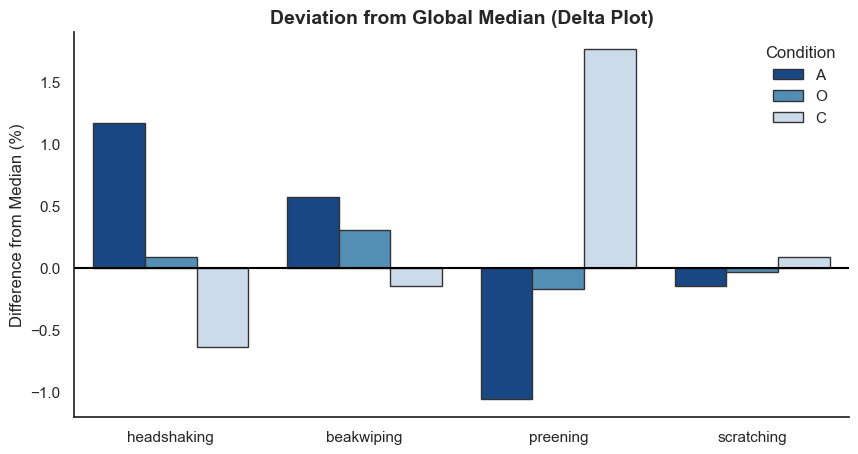

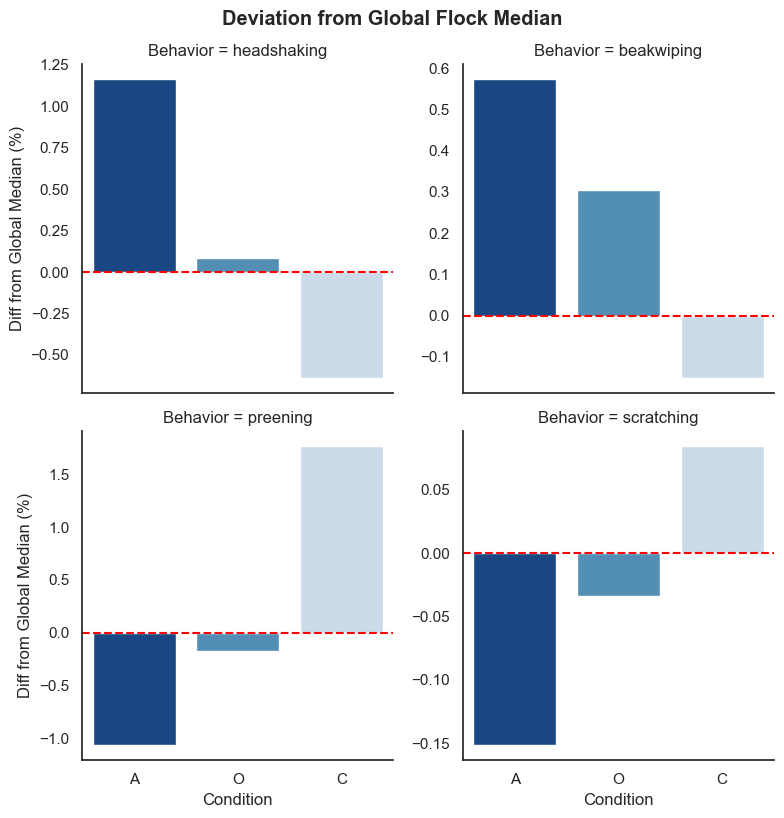

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_diff, 
    x="Behavior", 
    y="Difference", 
    hue="Condition", 
    hue_order=["A", "O", "C"],
    palette=color_palette,
    edgecolor=".2" # Sottile bordo scuro alle barre
)

# Linea dello zero più marcata
plt.axhline(0, color='black', linewidth=1.5)

plt.title("Deviation from Global Median (Delta Plot)", weight='bold', size=14)
plt.ylabel("Difference from Median (%)")
plt.xlabel("")
plt.legend(title="Condition", frameon=False)
sns.despine()
plt.show()

# 3.5 Delta BOXPLOT (Deviazione)
g = sns.FacetGrid(df_diff, col="Behavior", col_wrap=2, sharey=False, height=4)
g.map_dataframe(sns.barplot, x="Condition", y="Difference", palette=color_palette)

for ax in g.axes.flatten():
    ax.axhline(0, color='red', linestyle='--')
    
g.set_axis_labels("Condition", "Diff from Global Median (%)")
g.fig.suptitle("Deviation from Global Flock Median", fontweight='bold', y=1.02)
plt.show()

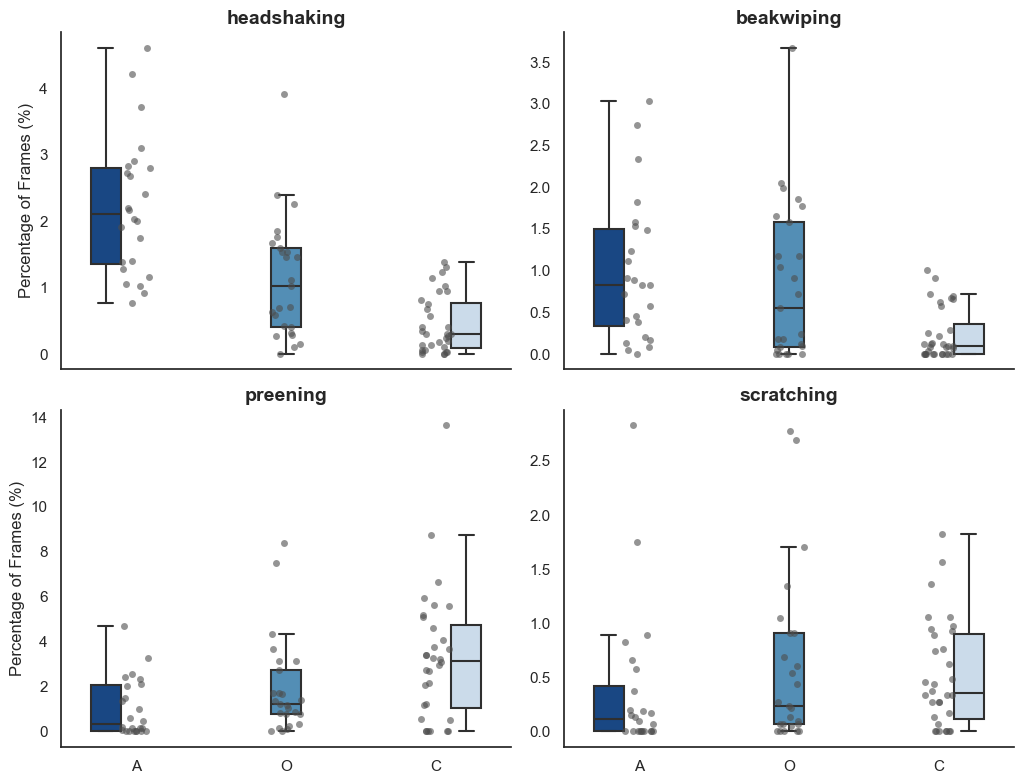

In [65]:

import warnings
# 1. Silenziamo i FutureWarning per pulire l'output della tesi
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Impostazioni grafiche richieste
color_palette = {"A": "#084594", "O": "#4292c6", "C": "#c6dbef"}
sns.set_theme(style="white")

# 2. Creazione FacetGrid
g = sns.FacetGrid(df, col="Behavior", col_wrap=2, sharey=False, height=4, aspect=1.3)

# 3. Mappiamo i Boxplot
g.map_dataframe(
    sns.boxplot, 
    x="Condition", 
    y="Percentage", 
    hue="Condition",
    palette=color_palette,
    hue_order=["A", "O", "C"],
    width=0.6,
    fliersize=0,      # Nascondiamo gli outlier duplicati (perché usiamo stripplot)
    linewidth=1.5
)

# 4. Aggiungiamo i singoli punti (Stripplot)
# Usiamo il nero con trasparenza per farli risaltare sopra il blu
g.map_dataframe(
    sns.stripplot, 
    x="Condition", 
    y="Percentage", 
    color=".3",       # Grigio scuro quasi nero
    alpha=0.6, 
    size=5,
    jitter=True       # Sparpaglia i punti per non sovrapporli
)

# 5. Pulizia estetica
g.set_axis_labels("", "Percentage of Frames (%)")
g.set_titles("{col_name}", weight='bold', size=14)
g.despine(left=False, bottom=False) # Rimuove i bordi superiore e destro

plt.tight_layout()
plt.show()

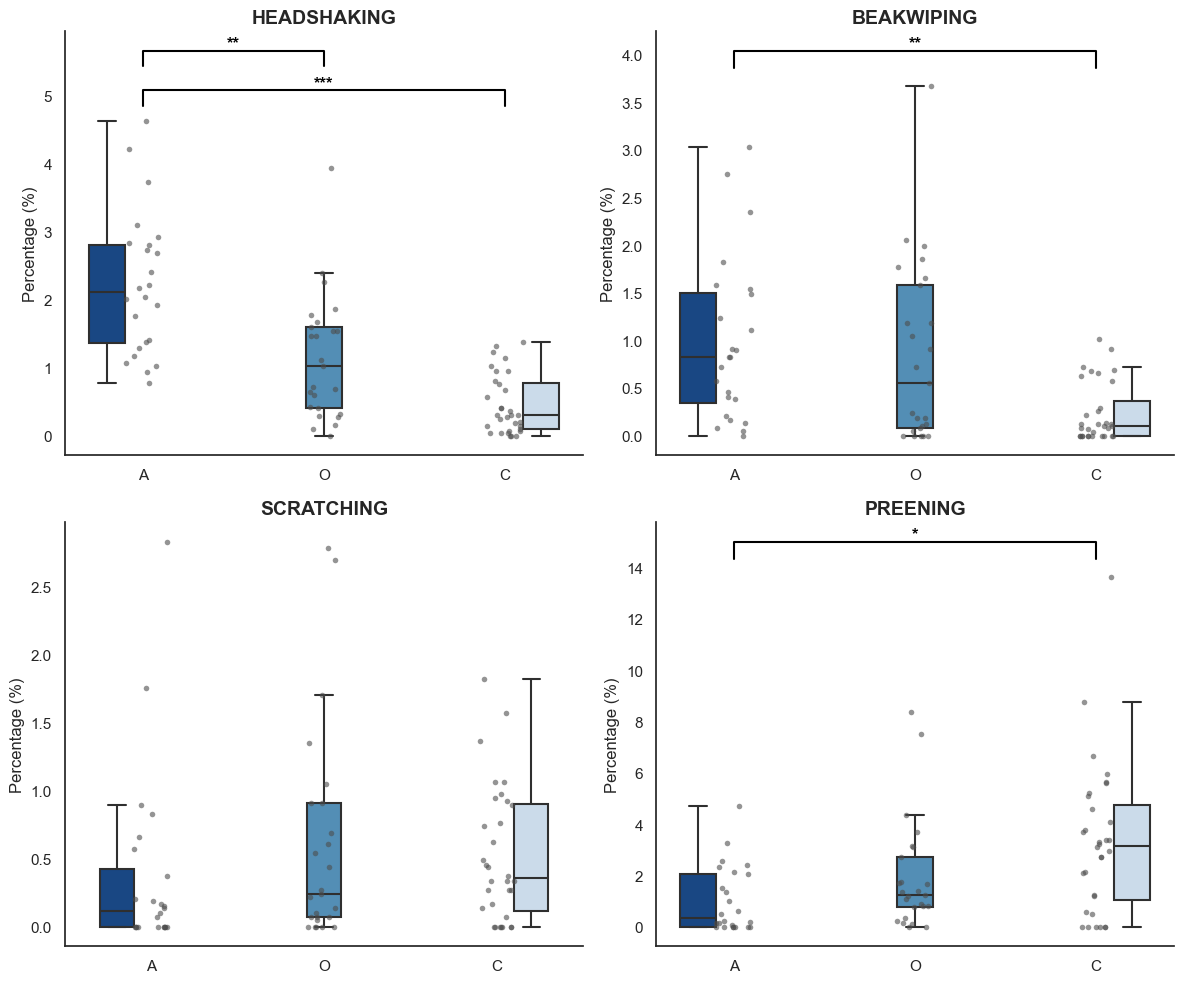

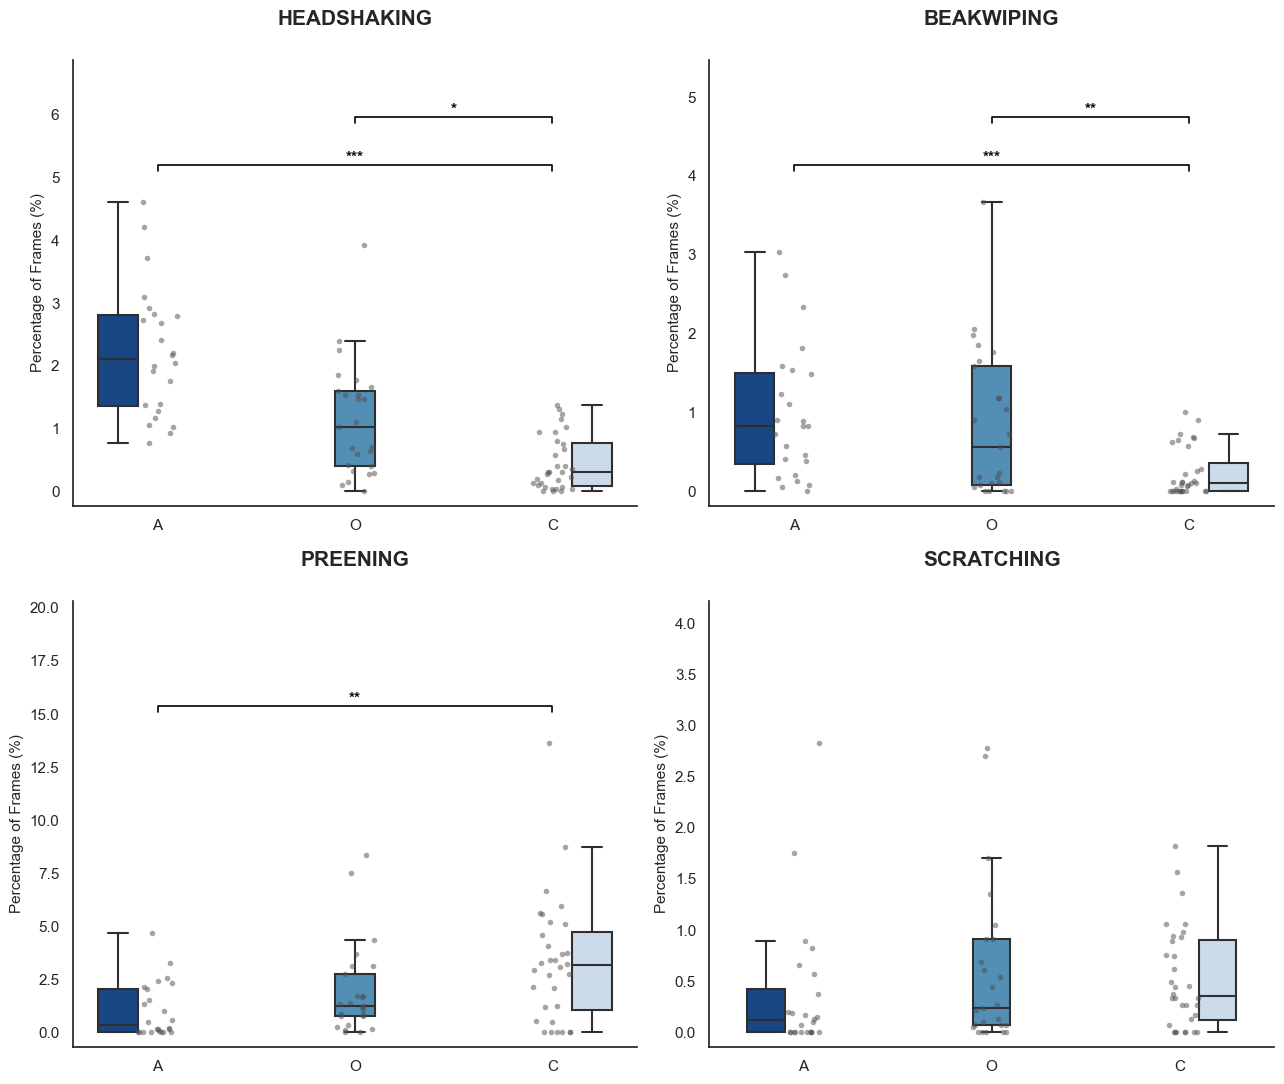

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Impostazioni grafiche
color_palette = {"A": "#084594", "O": "#4292c6", "C": "#c6dbef"}
sns.set_theme(style="white")

# 2. Creazione del grafico (usiamo i subplots per avere controllo totale sugli assi)
behaviors = df['Behavior'].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False)
axes = axes.flatten()

# Funzione per aggiungere la barretta manuale
def add_significance(ax, x1, x2, y, h, text):
    """Aggiunge una barra orizzontale con asterischi tra x1 e x2."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    ax.text((x1+x2)*0.5, y+h, text, ha='center', va='bottom', color='black', weight='bold')

for i, behavior in enumerate(behaviors):
    ax = axes[i]
    subset = df[df['Behavior'] == behavior]
    
    # Boxplot + Stripplot
    sns.boxplot(data=subset, x="Condition", y="Percentage", hue="Condition",
                palette=color_palette, hue_order=["A", "O", "C"], 
                width=0.6, fliersize=0, linewidth=1.5, ax=ax, legend=False)
    
    sns.stripplot(data=subset, x="Condition", y="Percentage", color=".3", 
                  alpha=0.6, size=4, jitter=True, ax=ax)
    
    ax.set_title(behavior.upper(), weight='bold', size=14)
    ax.set_xlabel("")
    ax.set_ylabel("Percentage (%)")
    
    # Calcoliamo l'altezza massima per posizionare le stelle
    y_max = subset['Percentage'].max()
    margin = y_max * 0.05
    
    # 3. AGGIUNGIAMO LE STELLE IN BASE AI RISULTATI CHE ABBIAMO VISTO
    # Nota: Le posizioni X sono A=0, O=1, C=2
    if behavior == 'headshaking':
        add_significance(ax, 0, 2, y_max + margin, margin, "***") # A vs C
        add_significance(ax, 0, 1, y_max + margin*3.5, margin, "**") # A vs O
        
    elif behavior == 'beakwiping':
        add_significance(ax, 0, 2, y_max + margin, margin, "**") # A vs C
        
    elif behavior == 'preening':
        add_significance(ax, 0, 2, y_max + margin, margin, "*")  # A vs C

sns.despine()
plt.tight_layout()
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurazione grafica
color_palette = {"A": "#084594", "O": "#4292c6", "C": "#c6dbef"}
sns.set_theme(style="white")

def get_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return None

def add_significance(ax, x1, x2, y, h, p_value):
    stars = get_stars(p_value)
    if stars:
        # Disegna la barra
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
        # Aggiunge le stelle
        ax.text((x1+x2)*0.5, y+h, stars, ha='center', va='bottom', 
                color='black', weight='bold', fontsize=11)

# 2. Inserimento dati Post-hoc dai tuoi screenshot
# Ho mappato esattamente i p.value dell'immagine
post_hoc_res = {
    'Beakwiping':  {'A-C': 0.0007, 'A-O': 0.8315, 'C-O': 0.0018},
    'Headshaking': {'A-C': 0.0001, 'A-O': 0.1563, 'C-O': 0.0253},
    'Preening':    {'A-C': 0.0070, 'A-O': 0.2134, 'C-O': 0.4651},
    'Scratching':  {'A-C': 0.4887, 'A-O': 0.4101, 'C-O': 0.9842}
}

# 3. Creazione Plot
behaviors = ['headshaking', 'beakwiping', 'preening', 'scratching']
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for i, behav_key in enumerate(behaviors):
    ax = axes[i]
    # Gestione maiuscole/minuscole per matchare il DF
    behav_label = behav_key.capitalize() if behav_key != 'headshaking' else 'Headshaking'
    subset = df[df['Behavior'].str.lower() == behav_key.lower()]
    
    # Boxplot + Stripplot
    sns.boxplot(data=subset, x="Condition", y="Percentage", hue="Condition",
                palette=color_palette, hue_order=["A", "O", "C"], 
                width=0.6, fliersize=0, linewidth=1.5, ax=ax, legend=False)
    
    sns.stripplot(data=subset, x="Condition", y="Percentage", color=".3", 
                  alpha=0.5, size=4, jitter=True, ax=ax)
    
    ax.set_title(behav_key.upper(), weight='bold', size=15, pad=25)
    ax.set_ylabel("Percentage of Frames (%)", size=11)
    ax.set_xlabel("")

    # Logica per le barre di significatività
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Recuperiamo i p-value per questo specifico comportamento
    # (Uso capitalize per sicurezza nel match col dizionario)
    res = post_hoc_res.get(behav_key.capitalize(), {})
    
    # Barra A vs C (Posizioni 0 e 2)
    add_significance(ax, 0, 2, y_max + y_range*0.05, y_range*0.02, res.get('A-C', 1.0))
    
    # Barra C vs O (Posizioni 2 e 1) - Solo se significativa
    # Nota: la tua immagine mostra C/O significativo per Beak e Head!
    add_significance(ax, 1, 2, y_max + y_range*0.20, y_range*0.02, res.get('C-O', 1.0))

    # Aggiustiamo il limite Y per non tagliare le stelle
    ax.set_ylim(y_min, y_max + y_range*0.4)

sns.despine()
plt.tight_layout()
plt.show()

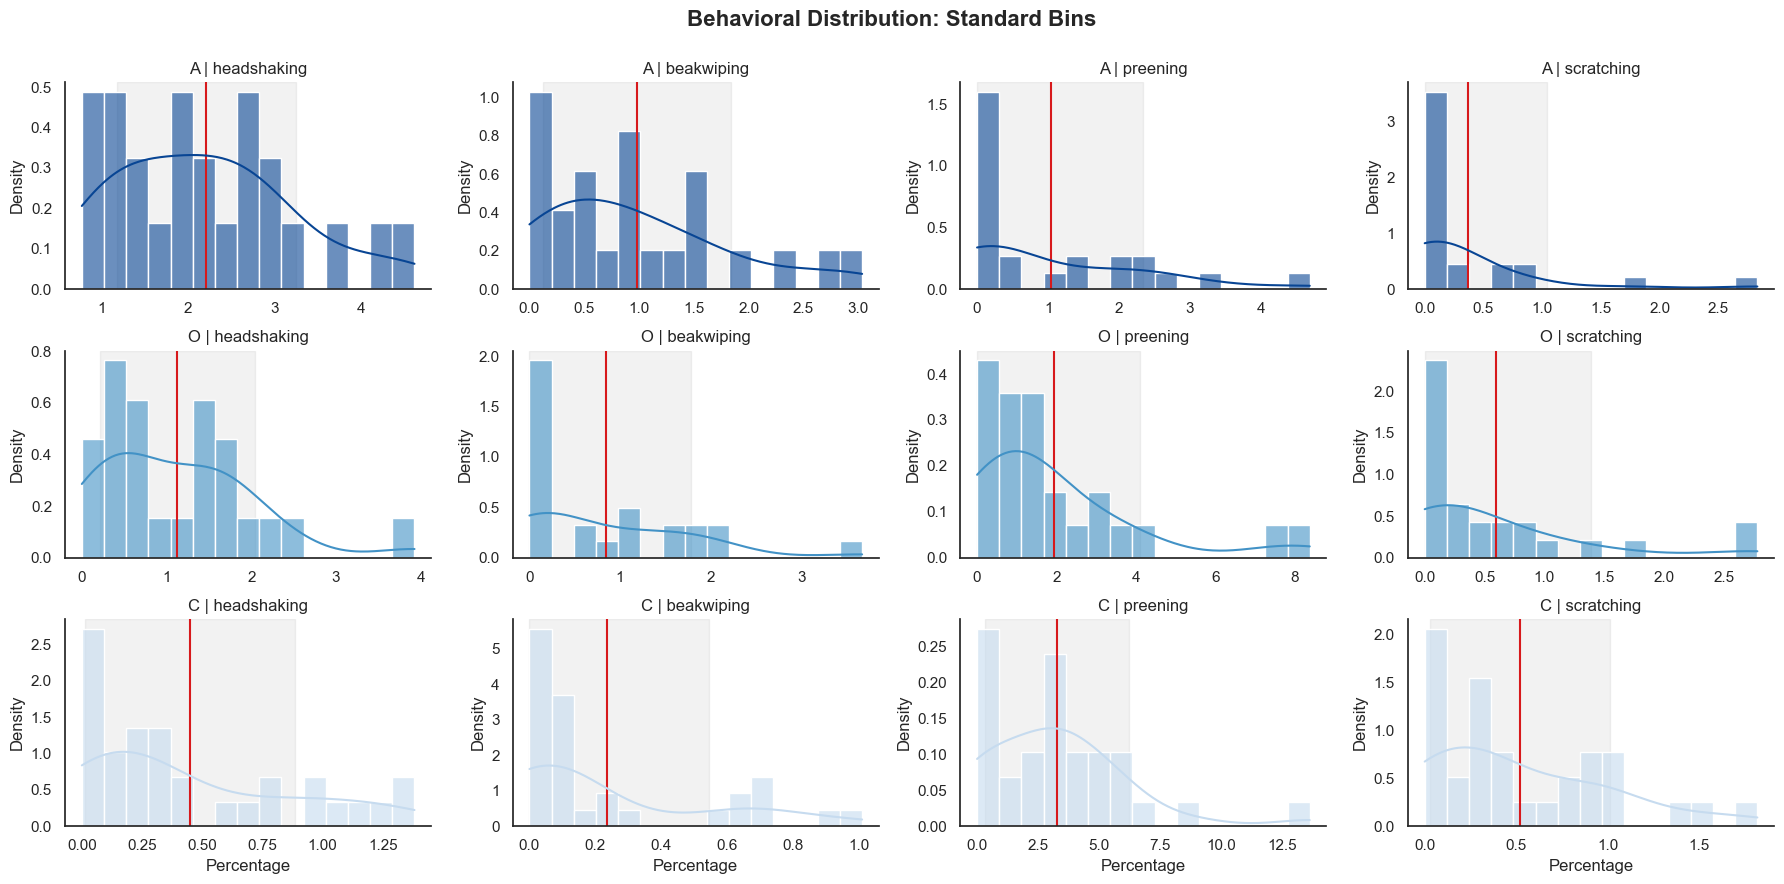

In [31]:
import matplotlib.patches as patches

# Calcolo statistiche per il background (SD)
stats_adv = df.groupby(['Condition', 'Behavior'])['Percentage'].agg(['mean', 'std']).reset_index()

def draw_histograms(n_bins, title):
    g = sns.FacetGrid(df, col="Behavior", row="Condition", hue="Condition", 
                      palette=color_palette, sharex=False, sharey=False, height=3, aspect=1.5)
    
    # A. Rettangolo SD Grigio
    for ax_key, ax in g.axes_dict.items():
        cond, beh = ax_key
        row_stats = stats_adv[(stats_adv['Condition'] == cond) & (stats_adv['Behavior'] == beh)]
        if not row_stats.empty:
            m, s = row_stats['mean'].values[0], row_stats['std'].values[0]
            ax.axvspan(max(0, m-s), m+s, color='grey', alpha=0.1, zorder=0) # Area SD
            ax.axvline(m, color='#D7191C', linestyle='-', linewidth=1.5)   # Linea Media
    
    # B. Istogramma e Densità
    g.map_dataframe(sns.histplot, x="Percentage", bins=n_bins, stat="density", common_norm=False, alpha=0.6, kde=True)
    
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Behavioral Distribution: {title}", fontsize=16, weight='bold')
    plt.show()

draw_histograms(15, "Standard Bins")

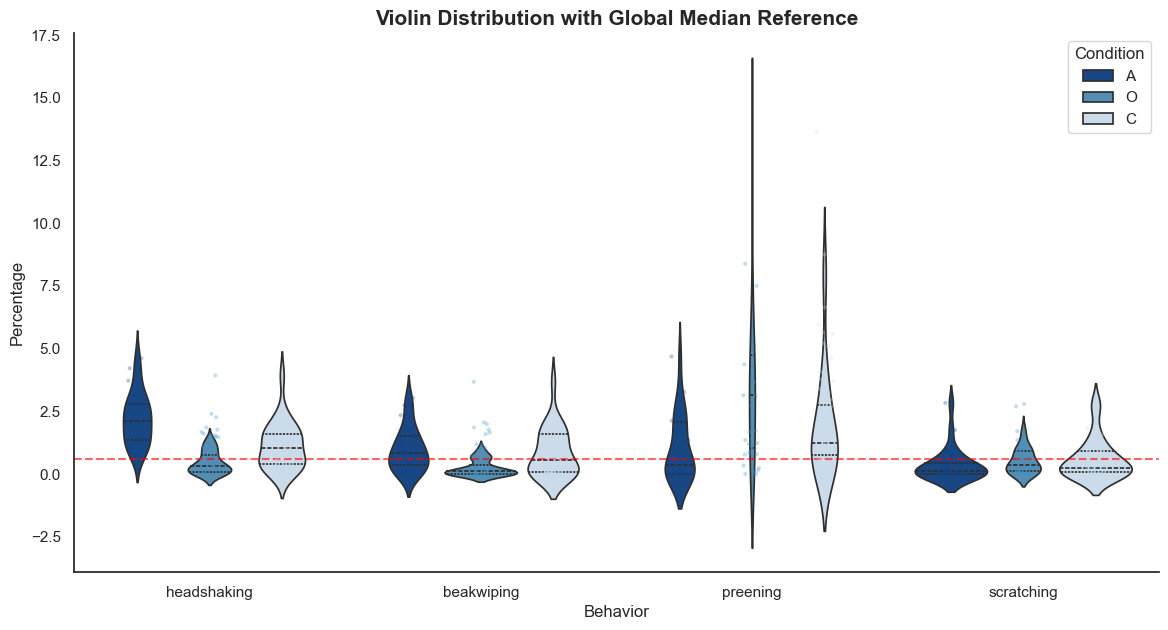

In [32]:
from statannotations.Annotator import Annotator

plt.figure(figsize=(14, 7))
ax = sns.violinplot(data=df, x="Behavior", y="Percentage", hue="Condition", 
                    palette=color_palette, hue_order=["A", "O", "C"], split=False, inner="quart")

# Aggiungiamo i punti jitterati sopra
sns.stripplot(data=df, x="Behavior", y="Percentage", hue="Condition", 
              palette=color_palette, hue_order=["A", "O", "C"], 
              dodge=True, color="black", alpha=0.3, size=3, legend=False)

# Linea mediana globale (rossa tratteggiata)
global_med = df['Percentage'].median()
plt.axhline(global_med, color='red', linestyle='--', alpha=0.6, label="Global Median")

plt.title("Violin Distribution with Global Median Reference", weight='bold', size=15)
sns.despine()
plt.show()

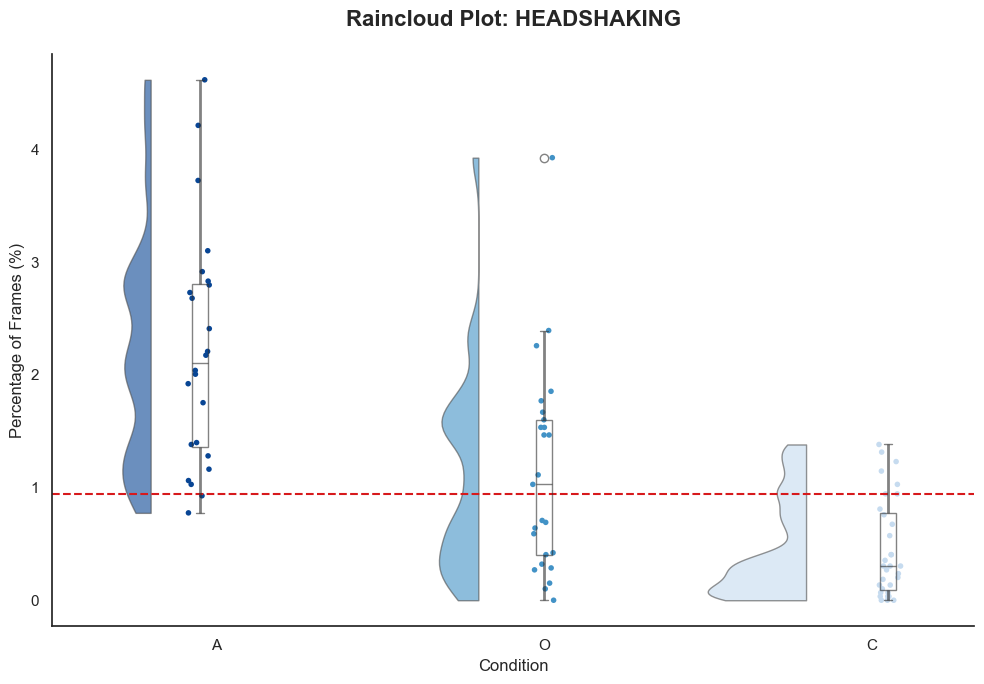

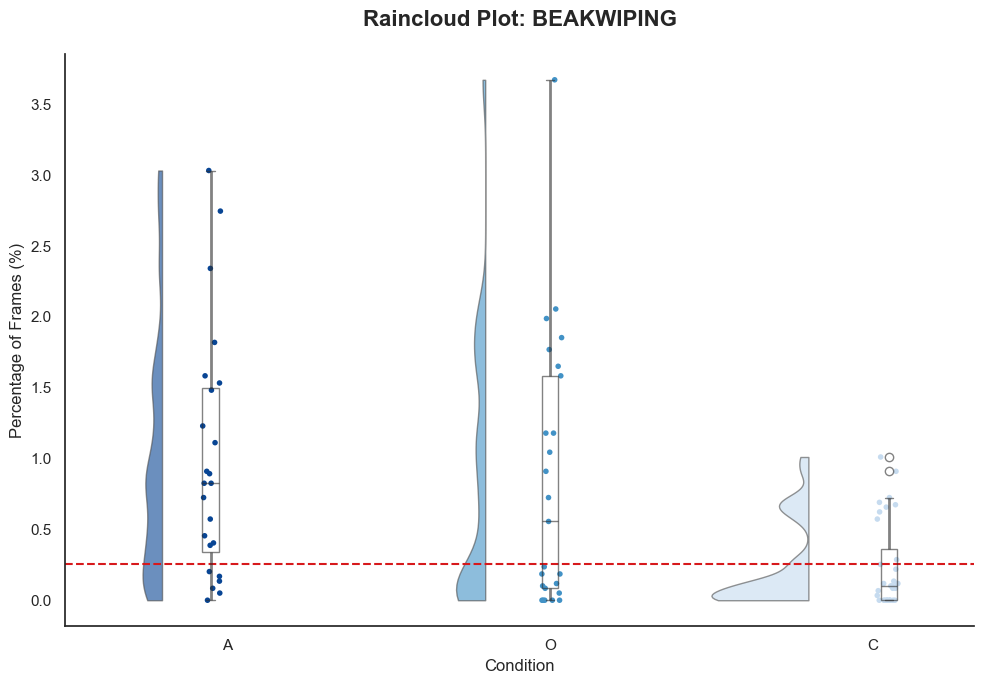

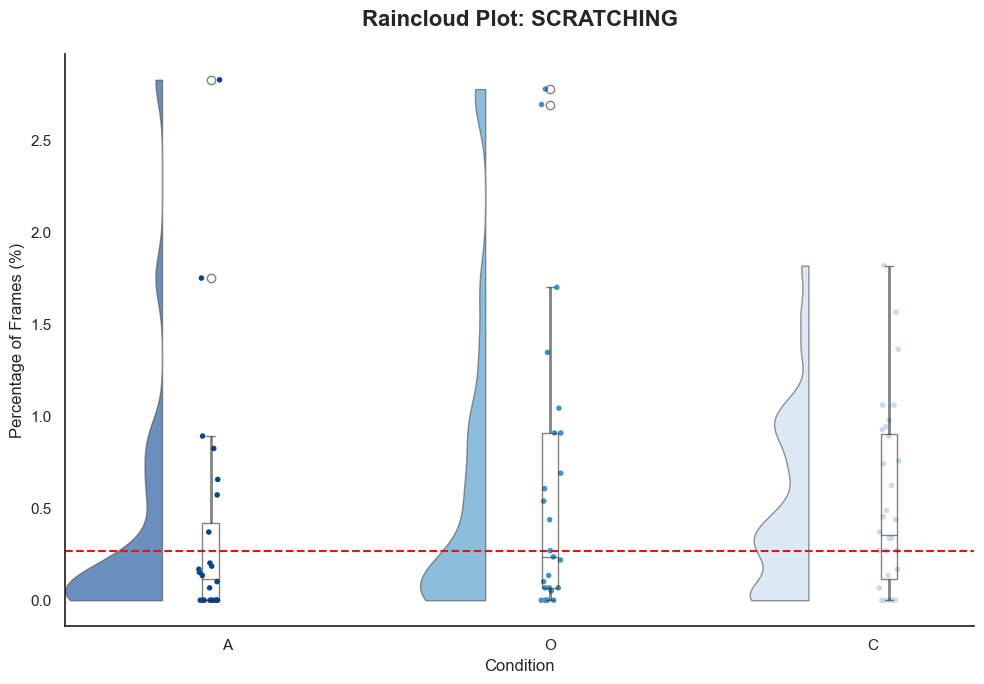

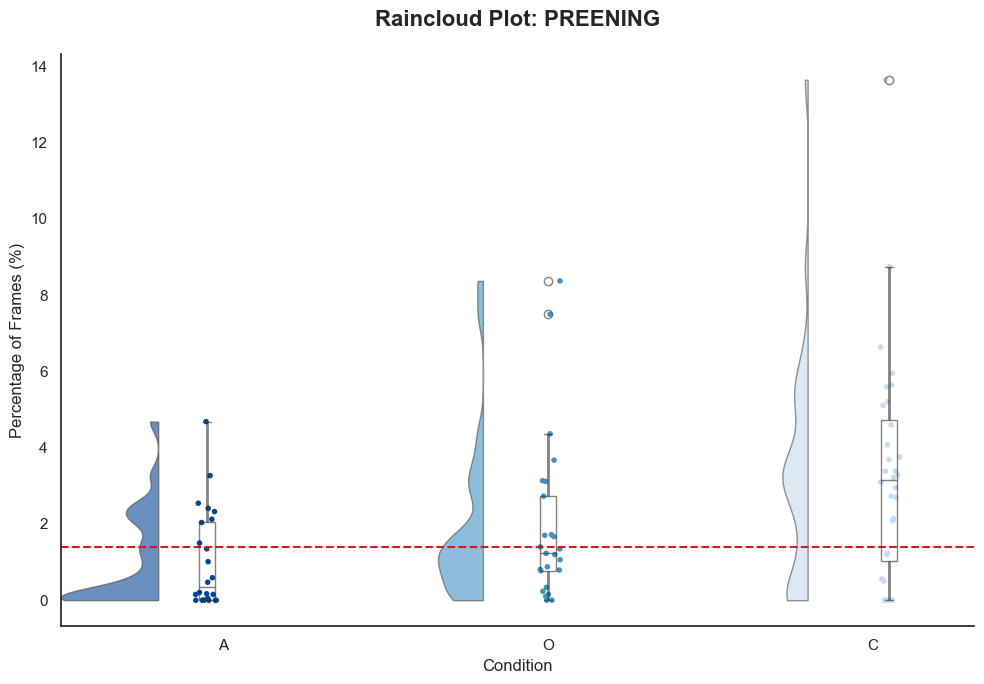

In [42]:
import warnings
import ptitprince as pt
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)
# Trasformiamo il dizionario in una lista ordinata per ptitprince
# Seguendo l'ordine A (scuro), O (medio), C (chiaro)
palette_list = [color_palette["A"], color_palette["O"], color_palette["C"]]

for beh in df['Behavior'].unique():
    fig, ax = plt.subplots(figsize=(10, 7))
    subset = df[df['Behavior'] == beh]
    
    # Creazione del Raincloud
    # Spostiamo i punti (stripplot) e regoliamo la nuvola (half-violin)
    pt.RainCloud(x="Condition", y="Percentage", data=subset, 
                 palette=palette_list, 
                 order=["A", "O", "C"],
                 width_viol=.6, 
                 width_box=.15, 
                 orient="v", 
                 alpha=.6, 
                 dodge=True,
                 ax=ax,
                 point_size=4)
    
    # Mediana globale specifica per comportamento (linea rossa tratteggiata)
    beh_med = subset['Percentage'].median()
    ax.axhline(beh_med, color='#D7191C', linestyle='--', linewidth=1.5, label="Global Median")
    
    # Estetica
    ax.set_title(f"Raincloud Plot: {beh.upper()}", fontsize=16, weight='bold', pad=20)
    ax.set_ylabel("Percentage of Frames (%)", fontsize=12)
    ax.set_xlabel("Condition", fontsize=12)
    
    sns.despine() # Pulisce i bordi del grafico
    plt.tight_layout()
    plt.show()



--- SPEARMAN CORRELATION SUMMARY: Headshaking vs Preening ---
Condition  Rho (ρ)  P-value Signif. Strength
        A   -0.037   0.8622      ns     Weak
        O   -0.288   0.1629      ns     Weak
        C    0.291   0.1065      ns     Weak
------------------------------------------------------------


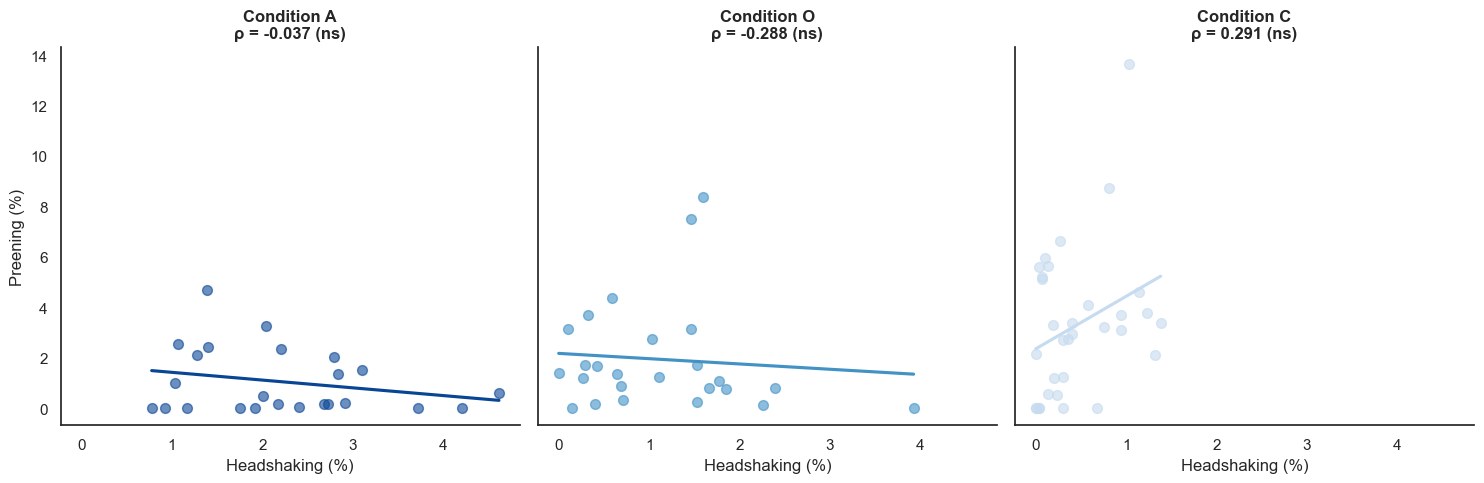

In [46]:
from scipy.stats import spearmanr
import pandas as pd

# =============================================================================
# 1. PREPARAZIONE DATI E CALCOLO CORRELAZIONI
# =============================================================================
# Creiamo il formato wide e riempiamo i vuoti con 0
df_corr = df.pivot_table(index=['Subject', 'Condition'], 
                         columns='Behavior', 
                         values='Percentage').fillna(0).reset_index()

corr_results = []

for cond in ["A", "O", "C"]:
    subset = df_corr[df_corr['Condition'] == cond]
    # Calcolo Spearman tra Headshaking e Preening
    rho, pval = spearmanr(subset['headshaking'], subset['preening'])
    
    # Definiamo la significatività con le classiche stelline
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    
    # Interpretazione della forza (secondo i canoni scientifici)
    strength = "Strong" if abs(rho) > 0.6 else "Moderate" if abs(rho) > 0.3 else "Weak"
    
    corr_results.append({
        'Condition': cond,
        'Rho (ρ)': round(rho, 3),
        'P-value': round(pval, 4),
        'Signif.': sig,
        'Strength': strength
    })

# Creiamo la tabella riassuntiva
summary_table = pd.DataFrame(corr_results)

# =============================================================================
# 2. STAMPA TABELLA E GENERAZIONE GRAFICO
# =============================================================================
print("\n" + "\033[1m" + "--- SPEARMAN CORRELATION SUMMARY: Headshaking vs Preening ---" + "\033[0m")
print(summary_table.to_string(index=False))
print("-" * 60)

# Generazione del grafico con lo stile che abbiamo scelto
g = sns.lmplot(data=df_corr, x="headshaking", y="preening", col="Condition", 
               hue="Condition", palette=color_palette, ci=None, 
               col_order=["A", "O", "C"], scatter_kws={"s": 50, "alpha": 0.6})

# Sincronizziamo i titoli dei grafici con i dati della tabella
for ax, cond in zip(g.axes.flat, ["A", "O", "C"]):
    row = summary_table[summary_table['Condition'] == cond].iloc[0]
    ax.set_title(f"Condition {cond}\nρ = {row['Rho (ρ)']} ({row['Signif.']})", 
                 weight='bold', size=12)
    ax.set_xlabel("Headshaking (%)")
    ax.set_ylabel("Preening (%)" if cond == "A" else "")

plt.tight_layout()
plt.show()

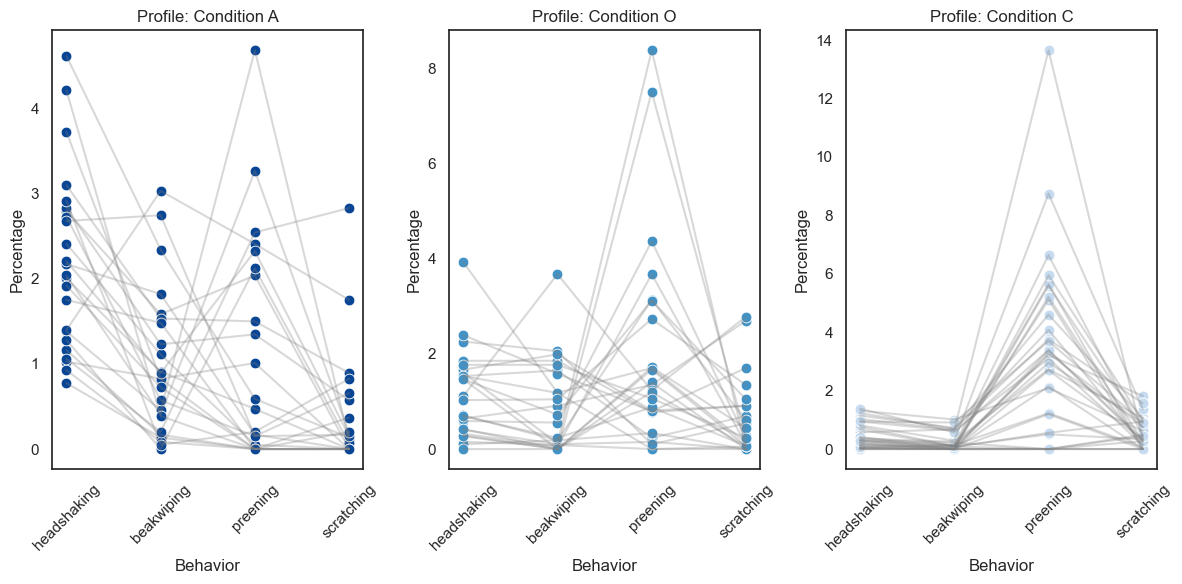

In [43]:
plt.figure(figsize=(12, 6))
for i, cond in enumerate(["A", "O", "C"]):
    plt.subplot(1, 3, i+1)
    subset = df[df['Condition'] == cond]
    
    # Linee che uniscono i punti dello stesso soggetto
    sns.lineplot(data=subset, x="Behavior", y="Percentage", units="Subject", 
                 estimator=None, color="grey", alpha=0.3)
    
    # Punti colorati
    sns.scatterplot(data=subset, x="Behavior", y="Percentage", color=color_palette[cond], s=60)
    
    plt.title(f"Profile: Condition {cond}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

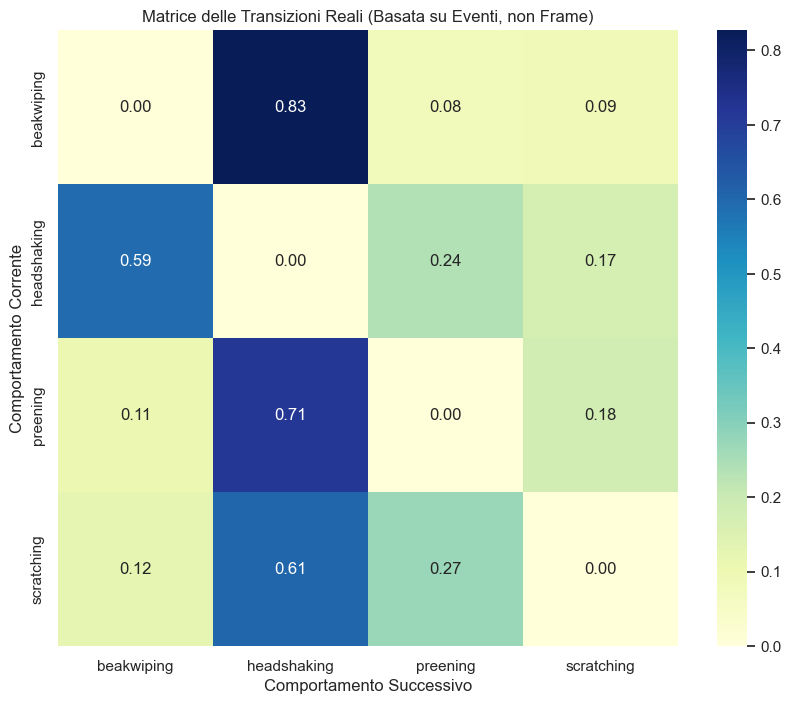

To           beakwiping  headshaking  preening  scratching
From                                                      
beakwiping     0.000000     0.827068  0.082707    0.090226
headshaking    0.591584     0.000000  0.237624    0.170792
preening       0.107143     0.714286  0.000000    0.178571
scratching     0.122807     0.605263  0.271930    0.000000


In [52]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Caricamento di tutti i fogli (ogni foglio = un soggetto)
path = r"D:\Serena_project_deepethogram\exported_labels.xlsx"
all_sheets = pd.read_excel(path, sheet_name=None)

behaviors_to_keep = ['headshaking', 'beakwiping', 'preening', 'scratching']
all_events = []

for subject_name, df_sheet in all_sheets.items():
    # Teniamo solo le colonne che ci interessano
    df_reduced = df_sheet[behaviors_to_keep]
    
    # Identifichiamo quale comportamento è attivo per ogni frame (riga)
    # idxmax ci dice la colonna che ha "1"
    active_behavior = df_reduced.idxmax(axis=1)
    
    # Rimuoviamo i frame dove sono tutti 0 (se presenti)
    active_behavior = active_behavior[df_reduced.sum(axis=1) > 0]
    
    # COMPRESSIONE: Teniamo il comportamento solo quando cambia
    # (es: da 0001111000 a solo un evento "1")
    change_mask = active_behavior != active_behavior.shift()
    events_sequence = active_behavior[change_mask].tolist()
    
    # Creiamo una lista di transizioni (A -> B) per questo soggetto
    for i in range(len(events_sequence) - 1):
        all_events.append({
            'Subject': subject_name,
            'From': events_sequence[i],
            'To': events_sequence[i+1]
        })

df_trans = pd.DataFrame(all_events)

# 2. Se hai un dizionario o una lista che associa Soggetti a Condizioni, applicala qui
# Esempio: cond_map = {"Sog_1": "A", "Sog_2": "O", ...}
# df_trans['Condition'] = df_trans['Subject'].map(cond_map)

# 3. Creazione Matrice di Transizione Globale
matrix = pd.crosstab(df_trans['From'], df_trans['To'], normalize='index')

# 4. Grafico
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Matrice delle Transizioni Reali (Basata su Eventi, non Frame)")
plt.ylabel("Comportamento Corrente")
plt.xlabel("Comportamento Successivo")
plt.show()

# 5. Tabella Risultati
print(matrix)

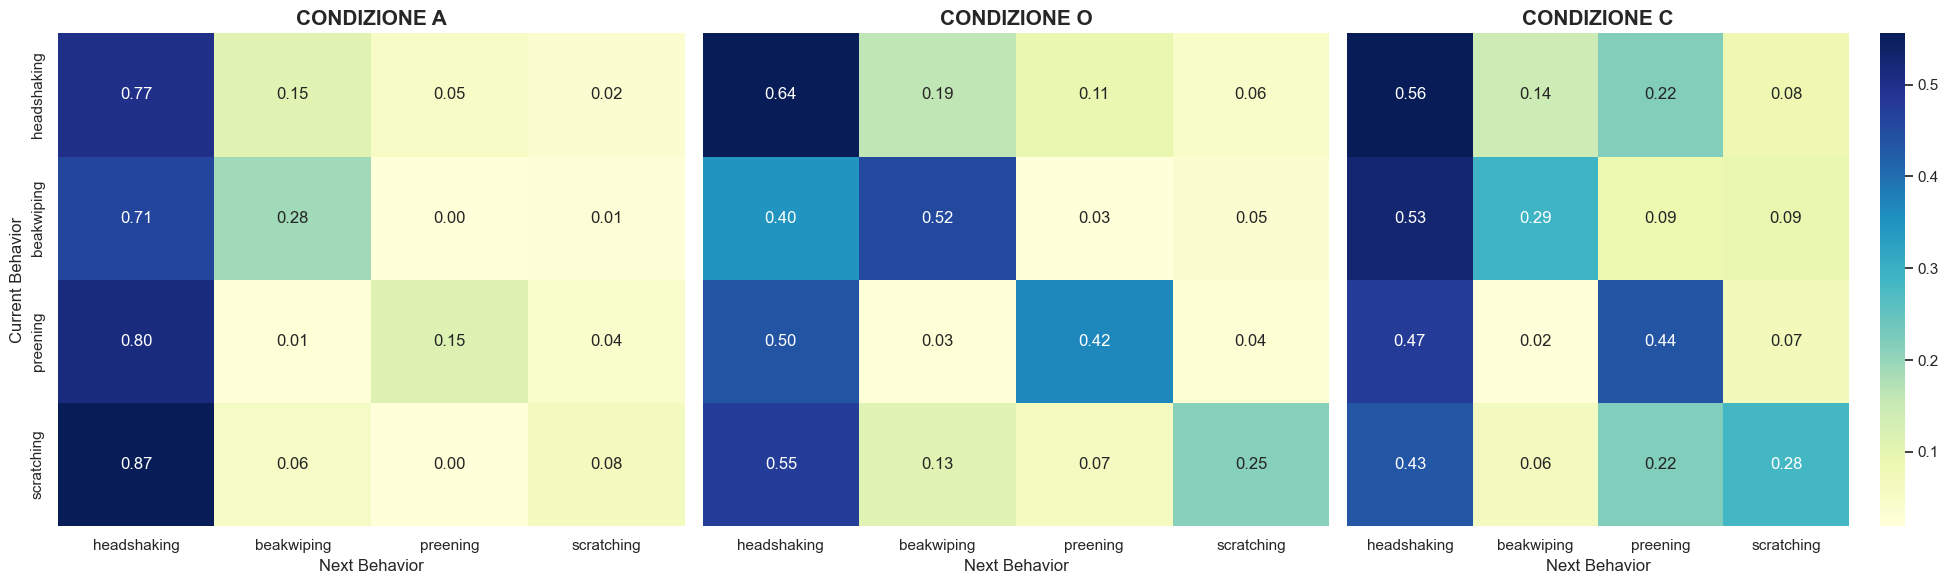

RIASSUNTO TRANSIZIONI COMPORTAMENTALI (Senza Background)
Cond Da (Current)    A (Next)  Probabilità  N transizioni
   A   scratching headshaking        0.865             45
   A     preening headshaking        0.800             84
   A  headshaking headshaking        0.775           1305
   A   beakwiping headshaking        0.713            248
   A   beakwiping  beakwiping        0.276             96
   A     preening    preening        0.152             16
   A  headshaking  beakwiping        0.147            247
   A   scratching  scratching        0.077              4
   A   scratching  beakwiping        0.058              3
   A  headshaking    preening        0.054             91
   A     preening  scratching        0.038              4
   A  headshaking  scratching        0.024             41
   A   beakwiping  scratching        0.011              4
   A     preening  beakwiping        0.010              1
   C  headshaking headshaking        0.556            418
   C   beakwipi

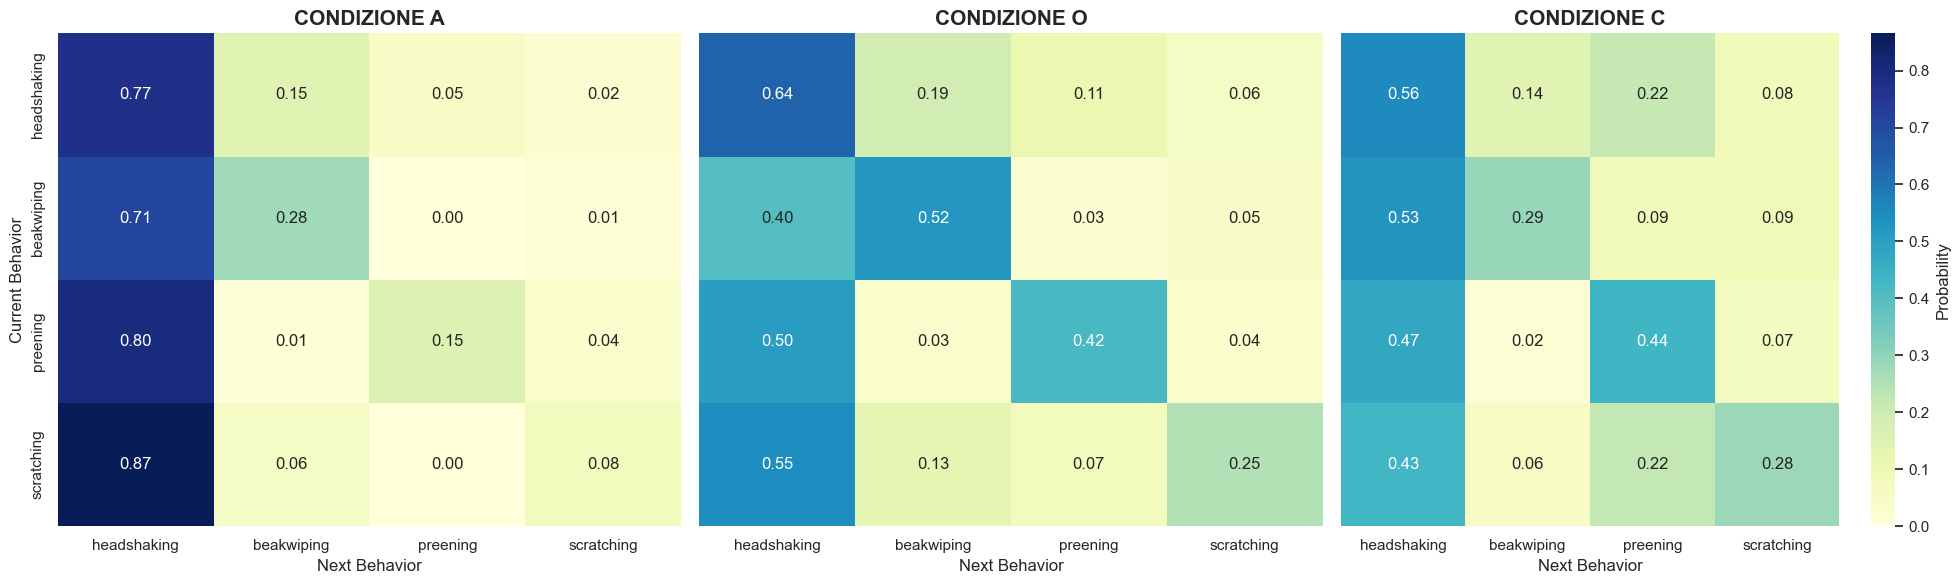

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Caricamento file
path = r"D:\Serena_project_deepethogram\exported_labels.xlsx"
all_sheets = pd.read_excel(path, sheet_name=None)

# Comportamenti principali
target_behavs = ['headshaking', 'beakwiping', 'preening', 'scratching']
# Includiamo il background solo per la compressione
all_behavs = target_behavs + ['background']

all_transitions = []

for subject_name, df_sheet in all_sheets.items():
    # Assegnazione condizione (A, O, C)
    if subject_name.upper().startswith('A'): cond = 'A'
    elif subject_name.upper().startswith('O'): cond = 'O'
    else: cond = 'C'

    # 2. Identificazione comportamento attivo
    # Selezioniamo le colonne se esistono, altrimenti saltiamo
    available_cols = [c for c in all_behavs if c in df_sheet.columns]
    df_reduced = df_sheet[available_cols]
    active_behavior = df_reduced.idxmax(axis=1)
    
    # 3. Compressione: Frame -> Eventi (incluso background)
    change_mask = active_behavior != active_behavior.shift()
    events_sequence = active_behavior[change_mask].tolist()
    
    # 4. Filtriamo la sequenza: rimuoviamo il background MA manteniamo l'ordine
    # Se avevamo [H, B, H], rimuovendo B resta [H, H], che crea la transizione H->H
    clean_sequence = [e for e in events_sequence if e != 'background']
    
    # 5. Creazione lista transizioni
    for i in range(len(clean_sequence) - 1):
        all_transitions.append({
            'Condition': cond,
            'From': clean_sequence[i],
            'To': clean_sequence[i+1]
        })

df_final = pd.DataFrame(all_transitions)

# 6. Visualizzazione 3 Matrici (Senza Background)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
conditions = ['A', 'O', 'C']

for i, cond in enumerate(conditions):
    subset = df_final[df_final['Condition'] == cond]
    
    if not subset.empty:
        # Creiamo la matrice di probabilità
        matrix = pd.crosstab(subset['From'], subset['To'], normalize='index')
        
        # Reindicizziamo per avere solo i 4 comportamenti e nello stesso ordine
        matrix = matrix.reindex(index=target_behavs, columns=target_behavs, fill_value=0)
        
        sns.heatmap(matrix, annot=True, cmap="YlGnBu", fmt=".2f", ax=axes[i], cbar=(i==2))
        axes[i].set_title(f"CONDIZIONE {cond}", weight='bold', size=15)
        axes[i].set_xlabel("Next Behavior")
        axes[i].set_ylabel("Current Behavior" if i==0 else "")

plt.tight_layout()
plt.show()


# =============================================================================
# SCRIPT PER TABELLA RIASSUNTIVA DELLE TRANSIZIONI (PER CONSULENZA)
# =============================================================================

summary_list = []

for cond in ['A', 'O', 'C']:
    subset = df_final[df_final['Condition'] == cond]
    
    if not subset.empty:
        # Calcoliamo le frequenze (quante volte accade A -> B)
        counts = pd.crosstab(subset['From'], subset['To'])
        # Calcoliamo le probabilità (normalizzate per riga)
        probs = pd.crosstab(subset['From'], subset['To'], normalize='index')
        
        for from_beh in target_behavs:
            for to_beh in target_behavs:
                # Recuperiamo i valori se esistono, altrimenti 0
                n = counts.loc[from_beh, to_beh] if from_beh in counts.index and to_beh in counts.columns else 0
                p = probs.loc[from_beh, to_beh] if from_beh in probs.index and to_beh in probs.columns else 0
                
                if n > 0: # Registriamo solo le transizioni effettivamente avvenute
                    summary_list.append({
                        'Cond': cond,
                        'Da (Current)': from_beh,
                        'A (Next)': to_beh,
                        'Probabilità': round(p, 3),
                        'N transizioni': int(n)
                    })

# Creiamo il DataFrame riassuntivo
df_summary_table = pd.DataFrame(summary_list)

# Ordiniamo per Condizione e poi per importanza (Probabilità)
df_summary_table = df_summary_table.sort_values(by=['Cond', 'Probabilità'], ascending=[True, False])

# Stampiamo la tabella
print("\033[1m" + "RIASSUNTO TRANSIZIONI COMPORTAMENTALI (Senza Background)" + "\033[0m")
print(df_summary_table.to_string(index=False))

# Salva in CSV se vuoi analizzarla con calma o mandarmela
# df_summary_table.to_csv("riassunto_transizioni.csv", index=False)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Caricamento e processamento (rimane uguale fino alla creazione di df_final)
# ... [assumo che df_final sia già popolato dallo script precedente] ...

# 2. Prepariamo le matrici per trovare il valore massimo globale (per la scala colori)
matrices = {}
vmax_global = 0

for cond in ['A', 'O', 'C']:
    subset = df_final[df_final['Condition'] == cond]
    if not subset.empty:
        # Calcoliamo la matrice
        m = pd.crosstab(subset['From'], subset['To'], normalize='index')
        # Reindicizziamo per essere sicuri che tutte le matrici abbiano le stesse righe/colonne
        m = m.reindex(index=behaviors_to_keep, columns=behaviors_to_keep, fill_value=0)
        matrices[cond] = m
        # Troviamo il valore massimo per settare la scala
        current_max = m.values.max()
        if current_max > vmax_global:
            vmax_global = current_max

# 3. Generazione dei 3 Subplots con SCALA UNIFICATA
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
conditions = ['A', 'O', 'C']

for i, cond in enumerate(conditions):
    if cond in matrices:
        # Usiamo vmin=0 e vmax=vmax_global (o 1.0) per bloccare la scala dei colori
        sns.heatmap(matrices[cond], 
                    annot=True, 
                    cmap="YlGnBu", 
                    fmt=".2f", 
                    ax=axes[i], 
                    vmin=0,           # Il bianco è sempre 0
                    vmax=vmax_global, # Il blu scuro è il massimo globale
                    cbar=(i==2),
                    cbar_kws={'label': 'Probability'} if i==2 else None)
        
        axes[i].set_title(f"CONDIZIONE {cond}", weight='bold', size=15)
        axes[i].set_xlabel("Next Behavior")
        axes[i].set_ylabel("Current Behavior" if i==0 else "")
    else:
        axes[i].set_title(f"CONDIZIONE {cond} - DATI ASSENTI")

plt.tight_layout()
plt.show()

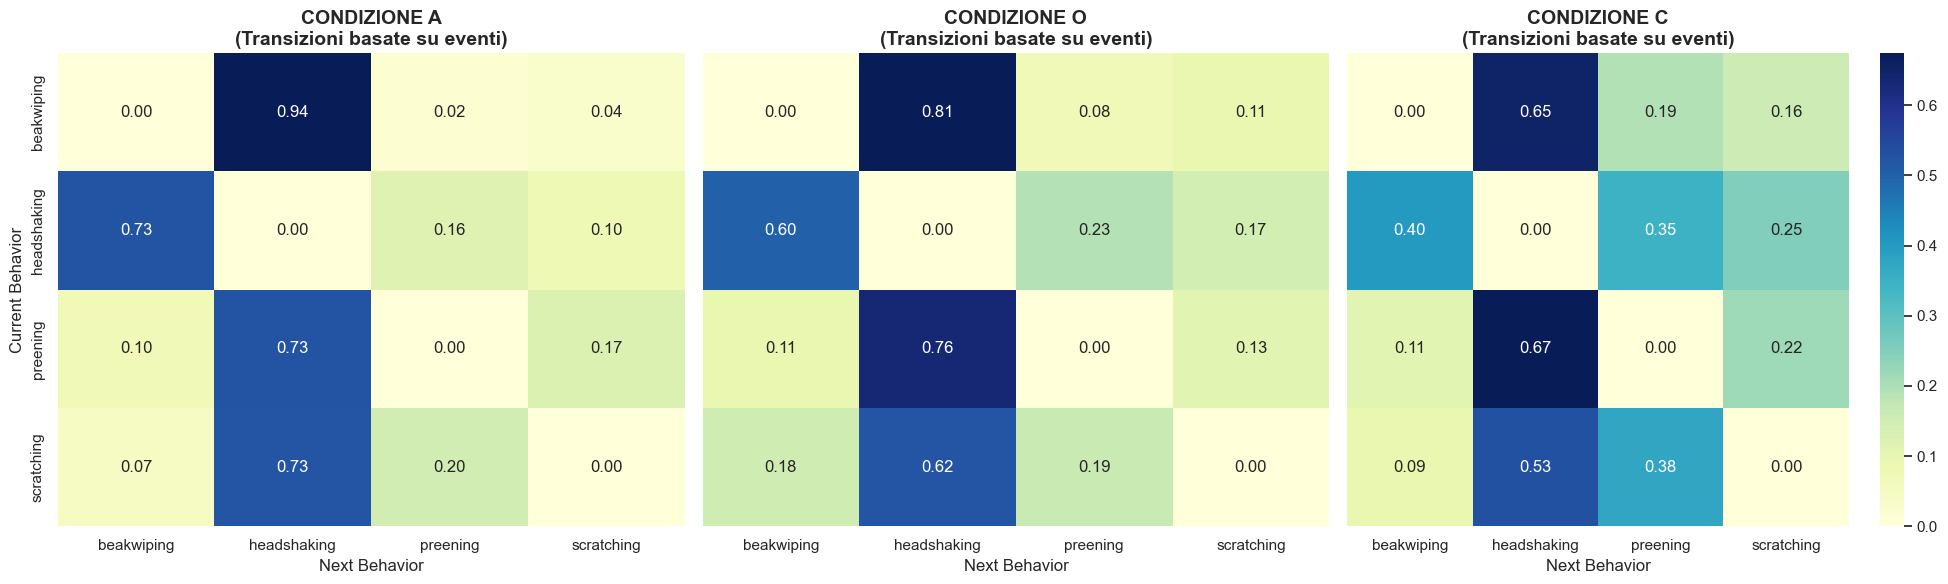

To                     beakwiping  headshaking  preening  scratching
Condition From                                                      
A         beakwiping            0          197         5           8
          headshaking         203            0        45          29
          preening              5           38         0           9
          scratching            3           32         9           0
C         beakwiping            0           71        21          17
          headshaking          88            0        76          55
          preening             14           87         0          28
          scratching            9           51        36           0
O         beakwiping            0          172        18          23
          headshaking         187            0        71          54
          preening             11           75         0          13
          scratching           16           55        17           0


In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Caricamento file
path = r"D:\Serena_project_deepethogram\exported_labels.xlsx"
all_sheets = pd.read_excel(path, sheet_name=None)

behaviors_to_keep = ['headshaking', 'beakwiping', 'preening', 'scratching']
all_transitions = []

# --- LOGICA DI ASSEGNAZIONE CONDIZIONI ---
# Modifica queste liste con i nomi esatti dei tuoi fogli se non iniziano con A, O, C
for subject_name, df_sheet in all_sheets.items():
    
    # Determiniamo la condizione (assumendo che il nome del foglio inizi con la lettera corretta)
    if subject_name.upper().startswith('A'):
        cond = 'A'
    elif subject_name.upper().startswith('O'):
        cond = 'O'
    else:
        cond = 'C'

    # 2. Pulizia e Compressione Frame -> Eventi
    df_reduced = df_sheet[behaviors_to_keep]
    active_behavior = df_reduced.idxmax(axis=1)
    
    # Escludiamo i frame dove sono tutti zero (background)
    active_behavior = active_behavior[df_reduced.sum(axis=1) > 0]
    
    # Compressione (teniamo solo il cambio di comportamento)
    change_mask = active_behavior != active_behavior.shift()
    events_sequence = active_behavior[change_mask].tolist()
    
    # Creazione lista transizioni
    for i in range(len(events_sequence) - 1):
        all_transitions.append({
            'Condition': cond,
            'From': events_sequence[i],
            'To': events_sequence[i+1]
        })

df_final = pd.DataFrame(all_transitions)

# 3. Generazione delle 3 Matrici (Subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
conditions = ['A', 'O', 'C']

for i, cond in enumerate(conditions):
    subset = df_final[df_final['Condition'] == cond]
    
    # Creiamo la matrice di probabilità
    if not subset.empty:
        matrix = pd.crosstab(subset['From'], subset['To'], normalize='index')
        
        # Plot
        sns.heatmap(matrix, annot=True, cmap="YlGnBu", fmt=".2f", ax=axes[i], cbar=(i==2))
        axes[i].set_title(f"CONDIZIONE {cond}\n(Transizioni basate su eventi)", weight='bold', size=14)
        axes[i].set_xlabel("Next Behavior")
        axes[i].set_ylabel("Current Behavior" if i==0 else "")
    else:
        axes[i].set_title(f"CONDIZIONE {cond} - DATI ASSENTI")

plt.tight_layout()
plt.show()

# 4. Print Tabella Riassuntiva per controllo
print(df_final.groupby(['Condition', 'From', 'To']).size().unstack(fill_value=0))

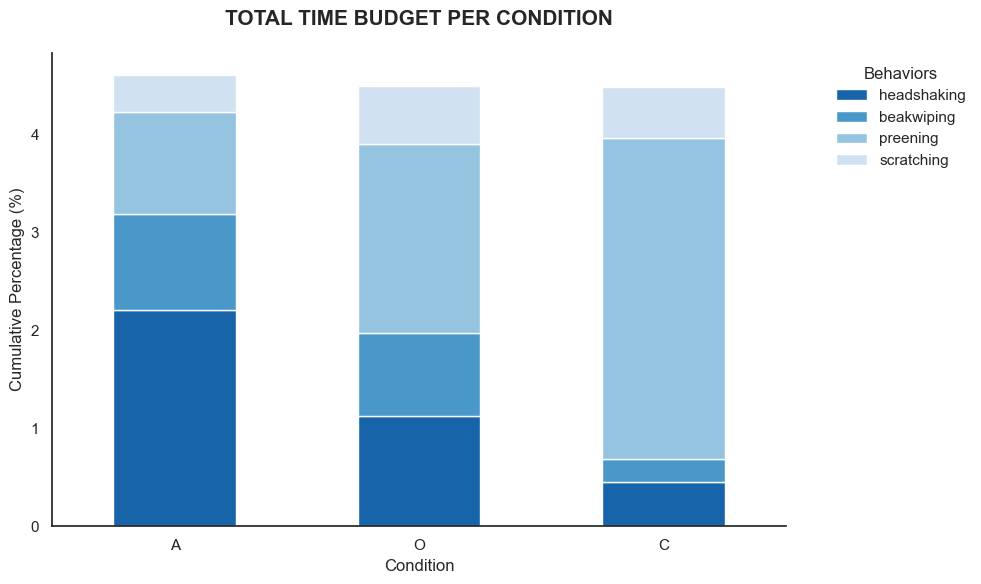


TABELLA RIASSUNTIVA: TIME BUDGET (%)
Behavior   headshaking  beakwiping  preening  scratching  TOTAL_SUM
Condition                                                          
A                 2.21        0.98      1.04        0.37       4.61
O                 1.13        0.85      1.93        0.60       4.50
C                 0.45        0.24      3.29        0.52       4.49


In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcolo del Time Budget (Medie per condizione)
time_budget = df.groupby(['Condition', 'Behavior'])['Percentage'].mean().unstack().fillna(0)
time_budget = time_budget.reindex(["A", "O", "C"])

# 2. Creazione della Tabella Riassuntiva (da printare)
# Calcoliamo anche una colonna "Total" per verifica (deve fare 100 o giù di lì)
summary_table = time_budget.copy()
summary_table['TOTAL_SUM'] = summary_table.sum(axis=1)

# 3. Plotting del Grafico (Senza numeri dentro)
colors = sns.color_palette("Blues_r", n_colors=len(time_budget.columns))
ax = time_budget.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title("TOTAL TIME BUDGET PER CONDITION", fontsize=15, weight='bold', pad=20)
plt.ylabel("Cumulative Percentage (%)", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Behaviors", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()

# 4. Visualizzazione Risultati
plt.show()

print("\n" + "="*60)
print("\033[1m" + "TABELLA RIASSUNTIVA: TIME BUDGET (%)" + "\033[0m")
print("="*60)
# Arrotondiamo a 2 decimali per la leggibilità
print(summary_table.round(2).to_string())
print("="*60)

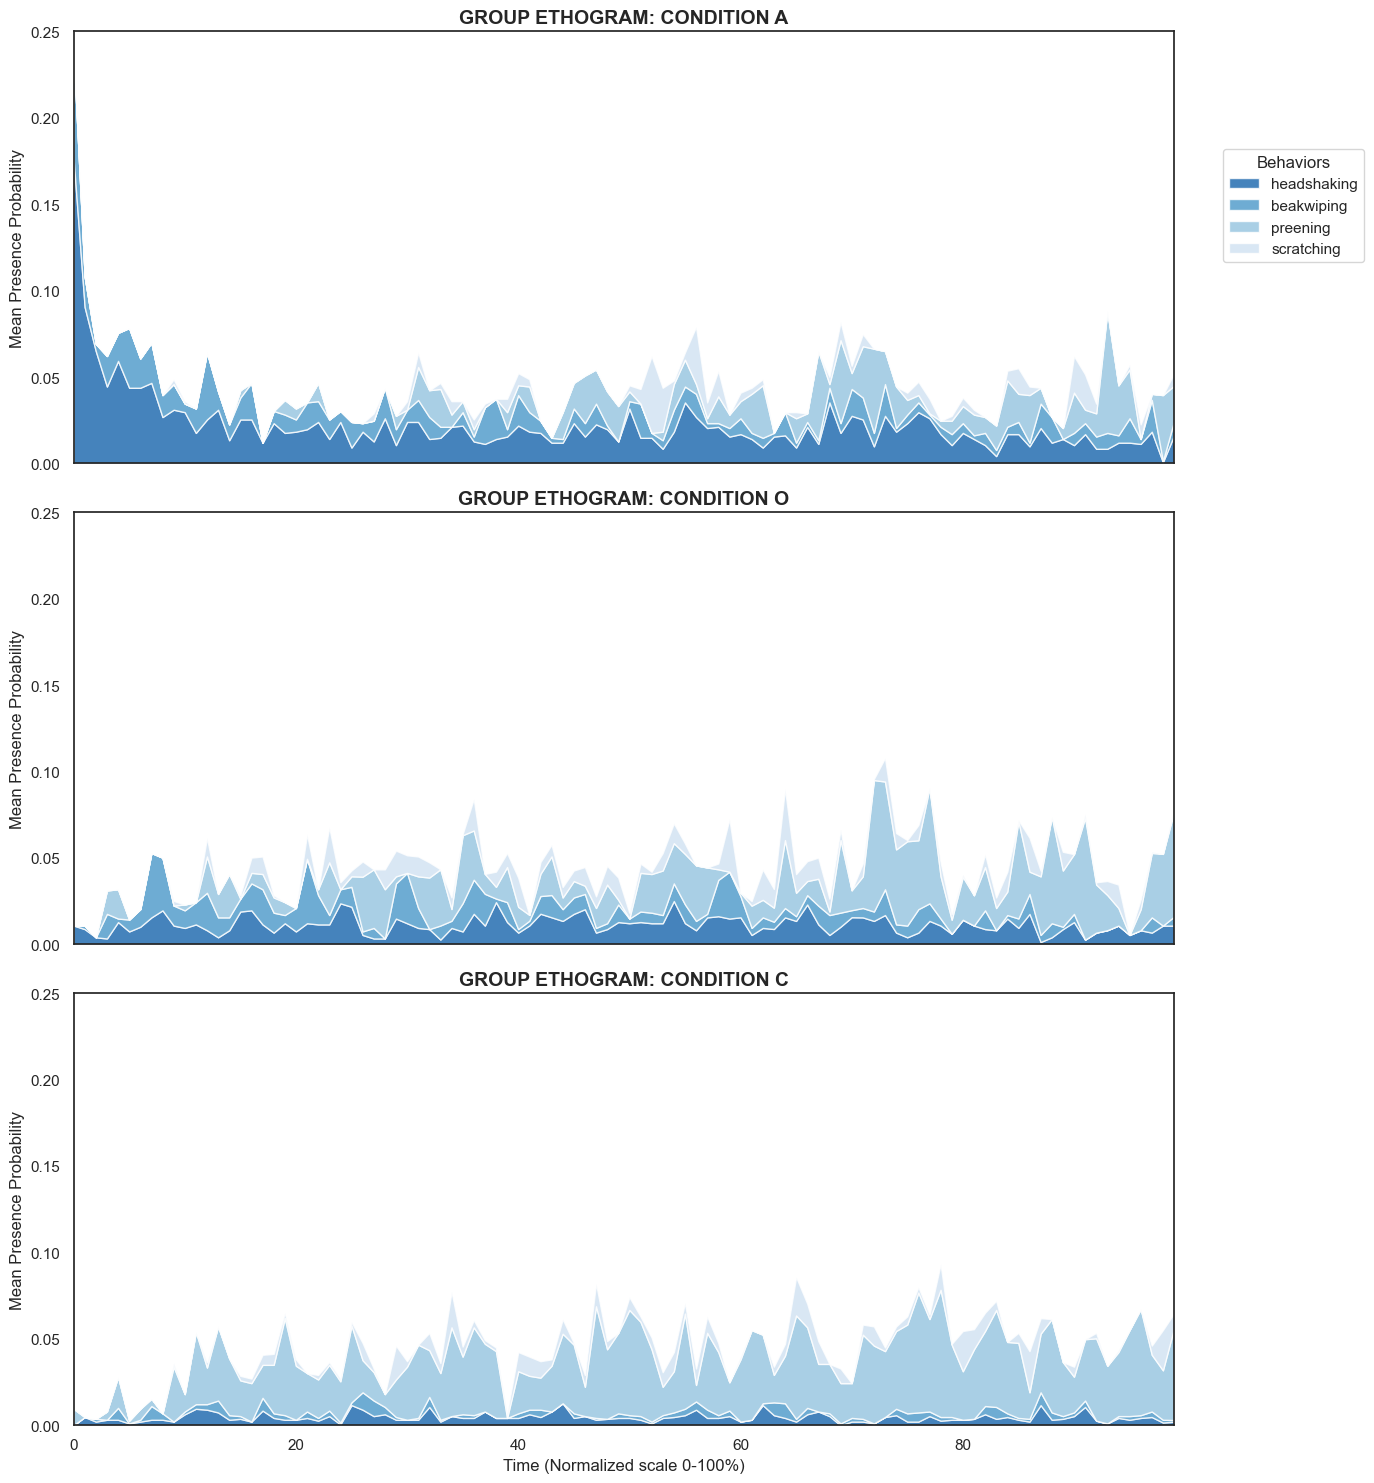

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Parametri
n_bins = 100
behaviors = ['headshaking', 'beakwiping', 'preening', 'scratching']
color_map = sns.color_palette("Blues_r", n_colors=len(behaviors))

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
conditions = ['A', 'O', 'C']

for i, cond in enumerate(conditions):
    ax = axes[i]
    group_data = []

    for subject_name, df_sheet in all_sheets.items():
        if subject_name.upper().startswith(cond):
            # Verifichiamo che le colonne esistano
            available_behavs = [b for b in behaviors if b in df_sheet.columns]
            
            # Usiamo il slicing di pandas invece di np.array_split per mantenere i metodi Pandas
            # O più semplicemente, calcoliamo i chunk manualmente
            chunk_size = len(df_sheet) // n_bins
            subject_probs = []
            
            for b in range(n_bins):
                start = b * chunk_size
                # L'ultimo bin prende tutto il resto per evitare buchi
                end = (b + 1) * chunk_size if b < n_bins - 1 else len(df_sheet)
                
                chunk = df_sheet[available_behavs].iloc[start:end]
                # Calcoliamo la media per ogni comportamento nel chunk
                subject_probs.append(chunk.mean(axis=0).fillna(0).values)
            
            group_data.append(subject_probs)

    if group_data:
        # group_data è (n_soggetti, 50_bins, 5_comportamenti)
        group_avg = np.mean(group_data, axis=0)
        df_plot = pd.DataFrame(group_avg, columns=behaviors)

        # 3. Plotting
        ax.stackplot(range(n_bins), 
                     *[df_plot[b] for b in behaviors], 
                     labels=behaviors, 
                     colors=color_map, 
                     alpha=0.8)

        ax.set_title(f"GROUP ETHOGRAM: CONDITION {cond}", weight='bold', size=14)
        ax.set_ylabel("Mean Presence Probability")
        ax.set_ylim(0, 0.25)
        ax.set_xlim(0, n_bins-1)
    else:
        ax.set_title(f"CONDITION {cond}: NO DATA FOUND")

# Estetica
axes[2].set_xlabel("Time (Normalized scale 0-100%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.15, 0.9), title="Behaviors")

plt.tight_layout()
plt.show()